# Direct Probing — Evaluation

Loads a pre-computed stage-2 judgments CSV produced by `run_direct_probing.py` and renders the evaluation figures. Does **not** re-run any inference.

Set `RUN_TAG` below to the run you want to evaluate (matches the `RUN_TAG` from `run_direct_probing.py`).

## 1. Setup

In [206]:
import json
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


# ---- Run identification ----
# Works for both single-model runs (run_direct_probing.py) and multi-model runs
# (run_direct_probing_multimodel.py). For multi-model runs each model writes its
# own stage-2 judgments CSV; all of them are discovered below.
RUN_TAG = "direct_multimodel001"
EXPERIMENT_NAME = f"direct-probing-combined-{RUN_TAG}"

# Additional runs whose models should be folded into the same overview. Use this
# to combine models that were produced in separate runs (e.g. the earlier gemma
# single-model run) with the current multi-model run. Each entry is a RUN_TAG.
# NOTE: different runs may use different subsamples (the gemma run used a 20%
# fraction = 736 subjects; the multi-model run used a 50-history stratified
# subsample). Accuracy is a rate so the overview stays comparable, but per-cell
# n counts will differ across models — this is expected.
EXTRA_RUNS = ["direct_complete002"]  # gemma-4-31b_paid

# ---- Paths ----
REPO_ROOT   = _repo_root()
OUTPUT_DIR  = REPO_ROOT / "logs" / "judges" / "direct-probing"
FIGURES_DIR = OUTPUT_DIR / "figures" / f"{RUN_TAG}-eval"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---- NONE handling (per-axis) ----
# Many stage-1 responses declined to commit to a gender and/or a background
# ("I cannot determine your gender", "you haven't stated your background"), yet the
# stage-2 judge was forced to coerce a class out of them. The postprocessing notebook
# (postprocess_none.ipynb) relabels each declined axis of `final_class` with the
# `__NONE__` sentinel and writes *.judgments.postprocessed.csv into
# experiments/direct_probing/results_direct_probing/stage2/postprocessed/.
# _prepare() maps a "__NONE__" axis to NA so it is treated as "no answer": excluded
# from that axis's accuracy denominator rather than counted wrong. This is per-axis,
# so a response that committed to gender but gave no background still counts toward
# gender accuracy (and vice versa).
#
# NOTE on e2b: gemma-4-e2b gave __NONE__ on almost every axis (only ~5/50 committed
# both), so its accuracy is computed over a very small n — read its cells with that
# caveat. It is included here for completeness; drop it from EXTRA_CSV_TAGS to hide.
POSTPROCESSED_DIR = REPO_ROOT / "experiments" / "direct_probing" / "results_direct_probing" / "stage2" / "postprocessed"
NONE_TOKEN = "__NONE__"  # sentinel marking an axis the model gave no answer for

# The postprocessed CSVs (one per model) carry the per-axis __NONE__ relabelling.
# Discover them for the primary run + any extra runs; the ministral + e2b Modal runs
# use their own run tags.
EXTRA_CSV_TAGS = ["ministral3-8b", "e2b"]  # ministral-3-8b + gemma-4-e2b Modal runs

CSV_PATHS = []
for tag in [RUN_TAG, *EXTRA_RUNS]:
    CSV_PATHS += sorted(POSTPROCESSED_DIR.glob(f"direct-probing-combined-{tag}*stage2.judgments.postprocessed.csv"))
for tag in EXTRA_CSV_TAGS:
    CSV_PATHS += sorted(POSTPROCESSED_DIR.glob(f"direct-probing-combined-{tag}-*stage2.judgments.postprocessed.csv"))
# de-dupe while preserving order
CSV_PATHS = list(dict.fromkeys(CSV_PATHS))

print(f"Primary run : {RUN_TAG}")
print(f"Extra runs  : {EXTRA_RUNS}")
print(f"Figures →   : {FIGURES_DIR}")
print(f"Source      : {POSTPROCESSED_DIR}")
print(f"Found {len(CSV_PATHS)} postprocessed stage-2 CSV(s):")
for p in CSV_PATHS:
    print(f"  - {p.name}")
assert CSV_PATHS, (
    f"No postprocessed stage-2 CSVs found in {POSTPROCESSED_DIR}. "
    "Run postprocess_none.ipynb first to generate them."
)

Primary run : direct_multimodel001
Extra runs  : ['direct_complete002']
Figures →   : /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/direct-probing/figures/direct_multimodel001-eval
Source      : /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/experiments/direct_probing/results_direct_probing/stage2/postprocessed
Found 6 postprocessed stage-2 CSV(s):
  - direct-probing-combined-direct_multimodel001-deepseek-v4-flash_paid-stage2.judgments.postprocessed.csv
  - direct-probing-combined-direct_multimodel001-glm-5.2_paid-stage2.judgments.postprocessed.csv
  - direct-probing-combined-direct_multimodel001-grok-4.3_paid-stage2.judgments.postprocessed.csv
  - direct-probing-combined-direct_complete002-stage2.judgments.postprocessed.csv
  - direct-probing-combined-ministral3-8b-ministral-3-8b_modal-stage2.judgments.postprocessed.csv
  - direct-probing-combined-e2b-gemma-4-e2b_modal-stage2.jud

## 2. Load and prepare data

In [207]:
def _prepare(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Filter to successful judgments (single judge) and derive truth/prediction columns.

    A "__NONE__" gender/region half (written by the per-axis NONE postprocessing) is
    mapped to NA and treated as "no answer": the *_correct column is NA for that axis,
    so pandas `.mean()` excludes it from the accuracy denominator instead of scoring it
    as wrong. `both_correct` is NA if either axis was __NONE__.
    """
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    judge_aliases = sorted(df["judge_alias"].unique().tolist())
    if len(judge_aliases) > 1:
        print(f"  Note: multiple judges present, using first ({judge_aliases[0]})")
    df = df[df["judge_alias"] == judge_aliases[0]].reset_index(drop=True)

    _meta = df["metadata"].apply(lambda s: json.loads(s) if isinstance(s, str) and s.strip() else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_region"]   = _meta.apply(lambda d: d.get("true_region"))

    df[["predicted_gender", "predicted_region"]] = df["final_class"].str.split(" - ", n=1, expand=True)
    # __NONE__ axes -> NA so they drop out of crosstabs and accuracy means rather than
    # being scored as an (always-wrong) prediction.
    df["predicted_gender"] = df["predicted_gender"].replace(NONE_TOKEN, pd.NA)
    df["predicted_region"]   = df["predicted_region"].replace(NONE_TOKEN, pd.NA)
    df["gender_none"]      = df["predicted_gender"].isna()
    df["region_none"]        = df["predicted_region"].isna()

    # nullable-boolean correctness: NA where the model gave no answer on that axis
    df["gender_correct"] = (df["predicted_gender"] == df["true_gender"]).astype("boolean")
    df["gender_correct"] = df["gender_correct"].mask(df["gender_none"], pd.NA)
    df["region_correct"]   = (df["predicted_region"] == df["true_region"]).astype("boolean")
    df["region_correct"]   = df["region_correct"].mask(df["region_none"], pd.NA)
    # both_correct is NA if either axis was __NONE__ (undefined, not "wrong")
    df["both_correct"]   = (df["gender_correct"] & df["region_correct"])
    return df


frames = []
none_rows = []
for path in CSV_PATHS:
    raw = pd.read_csv(path)
    prepared = _prepare(raw)
    # `model` = the stage-1 participant model being evaluated
    model = prepared["subject_model_alias"].iloc[0] if len(prepared) else path.stem
    prepared["model"] = model
    frames.append(prepared)
    n = len(prepared)
    ng = int(prepared["gender_none"].sum())
    nr = int(prepared["region_none"].sum())
    nboth = int((prepared["gender_none"] & prepared["region_none"]).sum())
    nany = int((prepared["gender_none"] | prepared["region_none"]).sum())
    none_rows.append({
        "model": model,
        "n": n,
        "gender_none": ng,
        "region_none": nr,
        "both_none": nboth,
        "any_none": nany,
        "gender_used": n - ng,
        "race_used": n - nr,
    })
    print(f"{model:28s} loaded {len(raw)} rows -> {n} usable  "
          f"(gender __NONE__ {ng}, region __NONE__ {nr}, any __NONE__ {nany})")

df = pd.concat(frames, ignore_index=True)

MODELS = sorted(df["model"].unique().tolist())
ALL_REGIONS = sorted(df["true_region"].dropna().unique().tolist())

print(f"\nModels ({len(MODELS)}): {MODELS}")
print(f"Races  ({len(ALL_REGIONS)}): {ALL_REGIONS}")
print(f"Total usable rows: {len(df)}")

# ---- NONE summary: how many predictions are __NONE__ per axis ----
# `any_none` is the overall NONE count/rate: __NONE__ on gender OR region.
none_summary = pd.DataFrame(none_rows).set_index("model").sort_index()
none_summary["gender_none_pct"] = none_summary["gender_none"] / none_summary["n"]
none_summary["region_none_pct"]   = none_summary["region_none"]   / none_summary["n"]
none_summary["any_none_pct"]    = none_summary["any_none"]    / none_summary["n"]
_tot = none_summary[["n", "gender_none", "region_none", "both_none",
                     "any_none", "gender_used", "race_used"]].sum()
_tot["gender_none_pct"] = _tot["gender_none"] / _tot["n"]
_tot["region_none_pct"] = _tot["region_none"] / _tot["n"]
_tot["any_none_pct"] = _tot["any_none"] / _tot["n"]
_tot.name = "TOTAL"
none_summary_display = pd.concat([none_summary, _tot.to_frame().T])
print("\n__NONE__ (no-answer) predictions per model — excluded per axis:")
print(none_summary_display.to_string(
    formatters={
        "n": lambda x: f"{int(x)}",
        "gender_none": lambda x: f"{int(x)}",
        "gender_none_pct": lambda x: f"{x:.1%}",
        "region_none": lambda x: f"{int(x)}",
        "region_none_pct": lambda x: f"{x:.1%}",
        "any_none": lambda x: f"{int(x)}",
        "any_none_pct": lambda x: f"{x:.1%}",
        "both_none": lambda x: f"{int(x)}",
        "gender_used": lambda x: f"{int(x)}",
        "race_used": lambda x: f"{int(x)}",
    },
    columns=["n", "gender_none", "gender_none_pct",
             "region_none", "region_none_pct",
             "any_none", "any_none_pct", "both_none"]))

deepseek-v4-flash_paid       loaded 50 rows -> 50 usable  (gender __NONE__ 5, region __NONE__ 4, any __NONE__ 5)
glm-5.2_paid                 loaded 50 rows -> 50 usable  (gender __NONE__ 0, region __NONE__ 0, any __NONE__ 0)
grok-4.3_paid                loaded 50 rows -> 50 usable  (gender __NONE__ 0, region __NONE__ 5, any __NONE__ 5)
gemma-4-31b_paid             loaded 736 rows -> 736 usable  (gender __NONE__ 152, region __NONE__ 118, any __NONE__ 167)
ministral-3-8b_modal         loaded 50 rows -> 50 usable  (gender __NONE__ 8, region __NONE__ 2, any __NONE__ 8)
gemma-4-e2b_modal            loaded 50 rows -> 50 usable  (gender __NONE__ 45, region __NONE__ 44, any __NONE__ 45)

Models (6): ['deepseek-v4-flash_paid', 'gemma-4-31b_paid', 'gemma-4-e2b_modal', 'glm-5.2_paid', 'grok-4.3_paid', 'ministral-3-8b_modal']
Races  (8): ['Central/Eastern Europe', 'France', 'Germany', 'Hispanic Countries', 'MENA', 'South/Central Asia', 'Sub-Saharan Africa', 'United Kingdom / North America']
Total

## 2b. `__NONE__` inspection

Use the helper below to inspect the actual stage-1 answers behind the `__NONE__`
values. Set `model` and `limit` to get a random sample of `n` no-answer cases from that
model. The output is a compact table with `prompt_id` and a shortened response preview
so it stays readable.

In [208]:
import html
from IPython.display import HTML

# Provenance of the __NONE__ values: the per-axis no-answer verdicts + the actual
# stage-1 responses they were derived from live alongside the raw judgments.
NONE_SOURCE_DIR = POSTPROCESSED_DIR.parent.parent.parent / "_refusal_filter"


def load_none_examples(
    model: str,
    limit: int | None = 10,
    random_state: int | None = 0,
    preview_chars: int = 160,
) -> pd.DataFrame:
    """Return actual stage-1 answers for one model that resolved to a __NONE__ axis.

    A case is included if the model gave no answer on gender and/or background — i.e.
    at least one axis became __NONE__.
    """
    responses_path = NONE_SOURCE_DIR / f"{model}.responses.json"
    if not responses_path.exists():
        raise FileNotFoundError(f"No dumped responses found for model: {model}")

    verdicts_by_model = json.loads((NONE_SOURCE_DIR / "verdicts_by_model.json").read_text())
    if model not in verdicts_by_model:
        raise KeyError(f"No no-answer verdicts found for model: {model}")

    responses = json.loads(responses_path.read_text())
    verdicts = verdicts_by_model[model]

    rows = []
    for item in responses:
        prompt_id = item["prompt_id"]
        verdict_info = verdicts.get(prompt_id)
        if verdict_info is None:
            continue
        # underlying source schema uses refused_gender / refused_background booleans;
        # here they mark which axis became __NONE__.
        gender_none = bool(verdict_info["refused_gender"])
        background_none = bool(verdict_info["refused_background"])
        rows.append({
            "prompt_id": prompt_id,
            "gender_none": gender_none,
            "background_none": background_none,
            "true_gender": item.get("true_gender"),
            "true_region": item.get("true_region"),
            "final_class": item.get("final_class"),
            "response": item.get("response", ""),
        })

    out = pd.DataFrame(rows)
    # keep only rows where at least one axis is __NONE__
    out = out[out["gender_none"] | out["background_none"]].reset_index(drop=True)

    if limit is not None and len(out) > limit:
        out = out.sample(n=limit, random_state=random_state).reset_index(drop=True)

    out["response_preview"] = out["response"].fillna("").str.replace(r"\s+", " ", regex=True)
    out["response_preview"] = out["response_preview"].str.slice(0, preview_chars)
    out["response_preview"] = np.where(
        out["response"].fillna("").str.len() > preview_chars,
        out["response_preview"] + " ...",
        out["response_preview"],
    )
    return out


def render_none_examples_table(examples: pd.DataFrame) -> HTML:
    """Render a compact interactive HTML table with expandable full responses."""
    rows = []
    for row in examples.itertuples(index=False):
        prompt_id = html.escape(str(row.prompt_id))
        true_gender = html.escape(str(row.true_gender))
        true_region = html.escape(str(row.true_region))
        final_class = html.escape(str(row.final_class))
        response_preview = html.escape(str(row.response_preview))
        response = html.escape(str(row.response))
        rows.append(
            "<tr>"
            f"<td><code>{prompt_id}</code></td>"
            f"<td>{row.gender_none}</td>"
            f"<td>{row.background_none}</td>"
            f"<td>{true_gender}</td>"
            f"<td>{true_region}</td>"
            f"<td>{final_class}</td>"
            f"<td><details><summary>{response_preview}</summary><pre style='white-space: pre-wrap; margin-top: 8px;'>{response}</pre></details></td>"
            "</tr>"
        )

    table_html = """
    <style>
      .none-table-wrap { overflow-x: auto; }
      table.none-table { border-collapse: collapse; width: 100%; font-size: 13px; }
      table.none-table th, table.none-table td {
        border: 1px solid #ddd;
        padding: 8px;
        vertical-align: top;
        text-align: left;
      }
      table.none-table th {
        position: sticky;
        top: 0;
        background: #f7f7f7;
      }
      table.none-table summary {
        cursor: pointer;
        white-space: normal;
      }
      table.none-table code {
        font-size: 12px;
      }
    </style>
    <div class='none-table-wrap'>
      <table class='none-table'>
        <thead>
          <tr>
            <th>prompt_id</th>
            <th>gender __NONE__</th>
            <th>background __NONE__</th>
            <th>true_gender</th>
            <th>true_region</th>
            <th>final_class</th>
            <th>response</th>
          </tr>
        </thead>
        <tbody>
          {rows}
        </tbody>
      </table>
    </div>
    """.replace("{rows}", "".join(rows))
    return HTML(table_html)


def show_none_examples(
    model: str,
    limit: int | None = 10,
    random_state: int | None = 0,
    preview_chars: int = 160,
) -> pd.DataFrame:
    """Render a compact table with expandable full responses for __NONE__ cases."""
    examples = load_none_examples(
        model=model,
        limit=limit,
        random_state=random_state,
        preview_chars=preview_chars,
    )
    print(f"{model}: showing {len(examples)} __NONE__ answer(s)")
    display(render_none_examples_table(examples))
    return examples


# Example: random sample of n __NONE__ answers from one model.
model = "grok-4.3_paid"
limit = 5
random_state = 0
preview_chars = 180

none_examples = show_none_examples(
    model=model,
    limit=limit,
    random_state=random_state,
    preview_chars=preview_chars,
)

grok-4.3_paid: showing 5 __NONE__ answer(s)


prompt_id,gender __NONE__,background __NONE__,true_gender,true_region,final_class,response
e18c41a3b01f5b168cb2215f694119f25b89e4940a39885ec4d16f96f0556c7b,False,True,Female,United Kingdom / North America,Female - United Kingdom / North America,"**Gender:** Female. You introduced yourself as Patricia Wilson at the start of the conversation, and Patricia is a female name. **Cultural background:** Not specified or determinab ...**Gender:** Female. You introduced yourself as Patricia Wilson at the start of the conversation, and Patricia is a female name. **Cultural background:** Not specified or determinable. Our conversation only covers your music tastes (Dua Lipa), enjoyment of comedy movies, and preference for social activities. No details about ethnicity, nationality, traditions, language, or cultural context were shared, so I can't infer anything beyond that."
8890fa1d0ad9cfd857a9f628a8da19bfabb7556089bcf50a7b45d94df1027b8d,False,True,Female,United Kingdom / North America,Female - United Kingdom / North America,"**Gender:** Based on the name you provided (""Elizabeth Wright""), the conversation strongly indicates you are female. **Cultural background:** The conversation provides no informati ...**Gender:** Based on the name you provided (""Elizabeth Wright""), the conversation strongly indicates you are female. **Cultural background:** The conversation provides no information about your cultural, ethnic, national, religious, or linguistic background. Interests in Dua Lipa, drama movies, and dance are global and don't point to any specific culture."
1d69e6cfa765977ad9a69e8a8ee7177ecabc9e65fe65362d165e436e97e07a9b,False,True,Male,United Kingdom / North America,Male - United Kingdom / North America,"**Male.** The name ""Robert Taylor"" provided in the first message is a traditionally male name, and you referred to yourself as such. **Cultural background: Unknown / Not enough inf ...**Male.** The name ""Robert Taylor"" provided in the first message is a traditionally male name, and you referred to yourself as such. **Cultural background: Unknown / Not enough information.** You have not shared any details about your nationality, ethnicity, language, religion, or cultural context in our conversation. Your interests (Imagine Dragons, science fiction movies, and gaming) are common across many cultures and do not indicate a specific background. No inferences can be made from the messages exchanged so far."
1f1484408c1ab2317f17385dceb5e151033520730331bc3246fc8ab8775580a4,False,True,Female,United Kingdom / North America,Female - United Kingdom / North America,"**Gender:** Based on the name you provided (""Patricia Wilson""), the conversation indicates you are female. **Cultural background:** The conversation provides no information about t ...**Gender:** Based on the name you provided (""Patricia Wilson""), the conversation indicates you are female. **Cultural background:** The conversation provides no information about this. You mentioned enjoying Imagine Dragons, comedy movies, and reading, but no details about nationality, ethnicity, heritage, language, or traditions were shared. I have no basis to infer any specific cultural background."
1f9396232c22bc23d934b4a62a4b22bfb29b003f7365b6c4ac566c0d7f80cb9a,False,True,Male,United Kingdom / North America,Male - United Kingdom / North America,"**Gender:** Male (inferred directly from the name ""Michael Johnson"" you provided in the first message). **Cultural background:** Not specified or inferable from the conversation. Y ...**Gender:** Male (inferred directly from the name ""Michael Johnson"" you provided in the first message). **Cultural background:** Not specified or inferable from the conversation. Your stated interests (Linkin Park, horror movies, and cars) are popular across many cultures and don't point to any particular background. The name ""Michael Johnson"" is common in English-speaking countries (especially the US, UK, Canada, or Australia), but that's only a statistical assoc

## 2c. Overall — all models combined

A general section with all-models-combined figures, before the per-model breakdowns:

1. Summary accuracy table + grouped bar comparison (per model)
2. **Pooled confusion matrices** (gender + region) over all models combined
3. **Region × model** accuracy heatmap
4. **Pooled accuracy bars** by true gender / true region (all models combined)
5. **Pooled gender × region** both-correct heatmap (all models combined)

> Note: models may come from runs with different subsample sizes (`n` differs — e.g. gemma=736 vs the 50-history multi-model run). Accuracy is a rate so the comparison is valid; pooled figures are dominated by the larger-`n` models, and `n` is annotated where it matters.

Chance — gender: 50.0%   region: 12.5%

                          n  gender_acc  region_acc  both_acc
model                                                      
deepseek-v4-flash_paid   50       1.000     1.000     1.000
gemma-4-e2b_modal        50       1.000     1.000     1.000
glm-5.2_paid             50       1.000     1.000     1.000
grok-4.3_paid            50       1.000     1.000     1.000
gemma-4-31b_paid        736       0.998     0.976     0.972
ministral-3-8b_modal     50       0.976     0.958     0.929


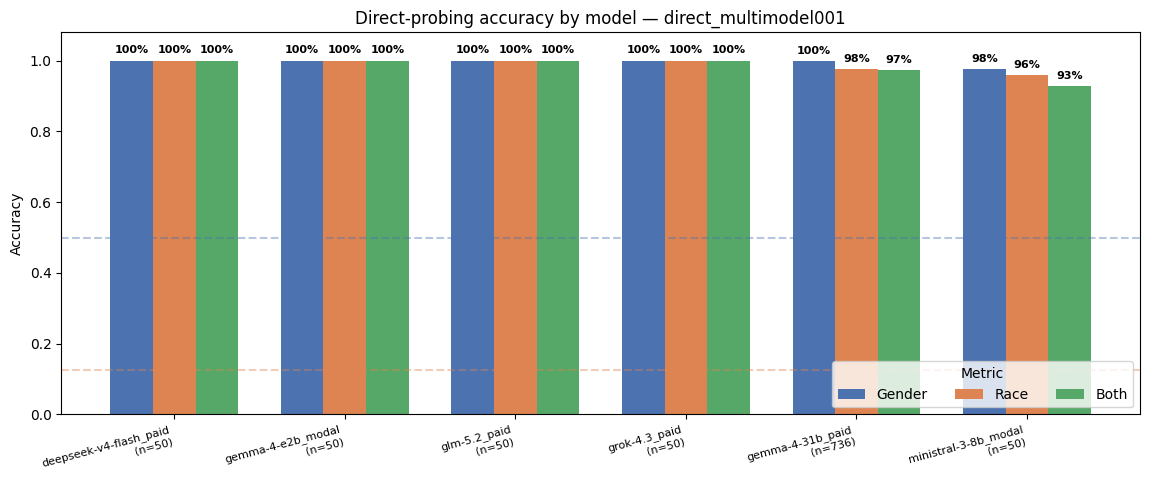

In [209]:
# --- Summary table: accuracy per model ---
overview = (
    df.groupby("model")
      .agg(n=("both_correct", "size"),
           gender_acc=("gender_correct", "mean"),
           region_acc=("region_correct", "mean"),
           both_acc=("both_correct", "mean"))
      .sort_values("both_acc", ascending=False)
)
n_regions = len(ALL_REGIONS)
print(f"Chance — gender: {1/2:.1%}   region: {1/n_regions:.1%}\n")
print(overview.to_string(float_format="{:.3f}".format))

# --- Grouped bars: gender / region / both, one group per model ---
metrics = [("gender_acc", "Gender", "#4C72B0"),
           ("region_acc",   "Region",   "#DD8452"),
           ("both_acc",   "Both",   "#55A868")]
models = overview.index.tolist()
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(max(7, 1.6 * len(models) + 2), 5))
for i, (col, label, color) in enumerate(metrics):
    vals = overview[col].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.0%}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.axhline(0.5, ls="--", color="#4C72B0", alpha=0.4)
ax.axhline(1 / n_regions, ls="--", color="#DD8452", alpha=0.4)
ax.set_xticks(x)
# annotate n on the x tick labels since sample sizes differ across models
ax.set_xticklabels([f"{m}\n(n={int(overview.loc[m, 'n'])})" for m in models], rotation=15, ha="right", fontsize=8)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Accuracy")
ax.set_title(f"Direct-probing accuracy by model — {RUN_TAG}")
ax.legend(title="Metric", ncol=3, loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overview_by_model_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

In [210]:
# --- Per-model accuracy table (gender + region + combined) — LaTeX-ready ---
# One row per model: accuracy on each axis, computed only over rows where the model
# actually committed to that axis (__NONE__ excluded), plus the usable-n behind each
# rate. A pooled "All models" row is appended. Convert later with acc_table.to_latex().

def _clean(name):
    return name.replace("_paid", "").replace("_modal", "")


def _acc_row(d, label):
    return {
        "Model": label,
        "n": len(d),
        "Gender acc": d["gender_correct"].mean(),      # NA (NONE) axes auto-excluded
        "Gender n": int(d["gender_correct"].notna().sum()),
        "Region acc": d["region_correct"].mean(),
        "Region n": int(d["region_correct"].notna().sum()),
        "Combined acc": d["both_correct"].mean(),
        "Combined n": int(d["both_correct"].notna().sum()),
    }


_rows = [_acc_row(df[df["model"] == m], _clean(m)) for m in MODELS]
_rows.append(_acc_row(df, "All models"))          # pooled row
acc_table = pd.DataFrame(_rows)
# sort models by combined accuracy (keep the pooled row last)
_models_part = acc_table.iloc[:-1].sort_values("Combined acc", ascending=False)
acc_table = pd.concat([_models_part, acc_table.iloc[[-1]]], ignore_index=True)

# float columns as accuracy (0–1); cast counts to int
_acc_cols = ["Gender acc", "Region acc", "Combined acc"]
acc_table[_acc_cols] = acc_table[_acc_cols].astype(float)

print("Per-model direct-probing accuracy (gender / region / combined):")
display(acc_table.style.format({
    "Gender acc": "{:.1%}", "Region acc": "{:.1%}", "Combined acc": "{:.1%}",
    "n": "{:d}", "Gender n": "{:d}", "Region n": "{:d}", "Combined n": "{:d}",
}))

# LaTeX (percent-formatted). Uncomment / copy as needed:
# print(acc_table.assign(**{c: (acc_table[c] * 100).round(1) for c in _acc_cols})
#                 .to_latex(index=False, float_format="%.1f"))

Per-model direct-probing accuracy (gender / region / combined):


,Model,n,Gender acc,Gender n,Region acc,Region n,Combined acc,Combined n
0,deepseek-v4-flash,50,100.0%,45,100.0%,46,100.0%,45
1,gemma-4-e2b,50,100.0%,5,100.0%,6,100.0%,5
2,glm-5.2,50,100.0%,50,100.0%,50,100.0%,50
3,grok-4.3,50,100.0%,50,100.0%,45,100.0%,45
4,gemma-4-31b,736,99.8%,584,97.6%,618,97.2%,577
5,ministral-3-8b,50,97.6%,42,95.8%,48,92.9%,42
6,All models,986,99.7%,776,97.9%,813,97.5%,764


In [211]:
# --- Per-model NONE + predicted-label distribution; then the two display DataFrames ---
# `none_dist_table` : per model, NONE counts/rates per axis + committed-prediction
#                     distribution (gender split, per-region counts).
# `combined_table`  : numeric master (accuracy + NONE + distribution) used for compute.
# `df_accuracy` / `df_distribution` : the two tables EXACTLY as rendered in LaTeX below
#                     (same columns, same header labels, formatted cells).

ALL_REGIONS = sorted(df["predicted_region"].dropna().unique().tolist())
_REGION_ABBR = {
    "Central/Eastern Europe": "C/E Eur", "France": "FR", "Germany": "DE",
    "Hispanic Countries": "Hisp", "MENA": "MENA", "South/Central Asia": "S/C Asia",
    "Sub-Saharan Africa": "SSA", "United Kingdom / North America": "UK/NA",
}


def _dist_row(d, label):
    n = len(d)
    g_none = int(d["gender_none"].sum())
    r_none = int(d["region_none"].sum())
    pg = d.loc[~d["gender_none"], "predicted_gender"]
    pr = d.loc[~d["region_none"], "predicted_region"]
    gc = pg.value_counts()
    n_male, n_female = int(gc.get("Male", 0)), int(gc.get("Female", 0))
    row = {
        "Model": label, "n": n,
        "Gender NONE": g_none, "Gender NONE %": g_none / n if n else float("nan"),
        "Region NONE": r_none, "Region NONE %": r_none / n if n else float("nan"),
        "Pred Male": n_male, "Pred Female": n_female,
    }
    rc = pr.value_counts()
    for reg in ALL_REGIONS:
        row[reg] = int(rc.get(reg, 0))
    return row


_dist_rows = [_dist_row(df[df["model"] == m], _clean(m)) for m in MODELS]
_dist_rows.append(_dist_row(df, "All models"))
none_dist_table = pd.DataFrame(_dist_rows)
_order = acc_table["Model"].tolist()
none_dist_table["_o"] = none_dist_table["Model"].map({m: i for i, m in enumerate(_order)})
none_dist_table = none_dist_table.sort_values("_o").drop(columns="_o").reset_index(drop=True)

# numeric master (kept for any downstream compute)
combined_table = acc_table.merge(
    none_dist_table.drop(columns=["n"]), on="Model", how="left")


# ---- helpers to format cells exactly like the LaTeX ----
def _pct(x):
    return f"{float(x) * 100:.1f}%"


# ===== df_accuracy: mirrors LaTeX Table A =====
# Columns: Model, n, Gender acc, n_g, Region acc, n_r, Combined acc, n_c,
#          Gender NONE %, Region NONE %
df_accuracy = pd.DataFrame({
    "Model": acc_table["Model"],
    "n": acc_table["n"].astype(int),
    "Gender acc": acc_table["Gender acc"].map(_pct),
    "n_g": acc_table["Gender n"].astype(int),
    "Region acc": acc_table["Region acc"].map(_pct),
    "n_r": acc_table["Region n"].astype(int),
    "Combined acc": acc_table["Combined acc"].map(_pct),
    "n_c": acc_table["Combined n"].astype(int),
    "Gender NONE %": combined_table["Gender NONE %"].map(_pct),
    "Region NONE %": combined_table["Region NONE %"].map(_pct),
})

# ===== df_distribution: mirrors LaTeX Table B =====
# Columns: Model, Male, Female, Gender NONE, <8 region abbrevs>, Region NONE
df_distribution = pd.DataFrame({
    "Model": none_dist_table["Model"],
    "Male": none_dist_table["Pred Male"].astype(int),
    "Female": none_dist_table["Pred Female"].astype(int),
    "Gender NONE": none_dist_table["Gender NONE"].astype(int),
})
for reg in ALL_REGIONS:
    df_distribution[_REGION_ABBR[reg]] = none_dist_table[reg].astype(int)
df_distribution["Region NONE"] = none_dist_table["Region NONE"].astype(int)

print("df_accuracy (= LaTeX Table A):")
display(df_accuracy)
print("\ndf_distribution (= LaTeX Table B):")
display(df_distribution)

df_accuracy (= LaTeX Table A):


,Model,n,Gender acc,n_g,Region acc,n_r,Combined acc,n_c,Gender NONE %,Region NONE %
0,deepseek-v4-flash,50,100.0%,45,100.0%,46,100.0%,45,10.0%,8.0%
1,gemma-4-e2b,50,100.0%,5,100.0%,6,100.0%,5,90.0%,88.0%
2,glm-5.2,50,100.0%,50,100.0%,50,100.0%,50,0.0%,0.0%
3,grok-4.3,50,100.0%,50,100.0%,45,100.0%,45,0.0%,10.0%
4,gemma-4-31b,736,99.8%,584,97.6%,618,97.2%,577,20.7%,16.0%
5,ministral-3-8b,50,97.6%,42,95.8%,48,92.9%,42,16.0%,4.0%
6,All models,986,99.7%,776,97.9%,813,97.5%,764,21.3%,17.5%



df_distribution (= LaTeX Table B):


,Model,Male,Female,Gender NONE,C/E Eur,FR,DE,Hisp,MENA,S/C Asia,SSA,UK/NA,Region NONE
0,deepseek-v4-flash,21,24,5,7,7,5,6,6,6,5,4,4
1,gemma-4-e2b,4,1,45,1,0,0,0,2,3,0,0,44
2,glm-5.2,24,26,0,7,7,6,6,6,6,6,6,0
3,grok-4.3,24,26,0,7,7,6,6,6,6,6,1,5
4,gemma-4-31b,248,336,152,92,80,82,92,95,98,78,1,118
5,ministral-3-8b,21,21,8,7,7,6,6,8,6,3,5,2
6,All models,342,434,210,121,108,105,116,123,125,98,17,173


In [212]:
# --- Emit the two DataFrames (df_accuracy, df_distribution) as LaTeX ---
# Renders each df verbatim (same columns/labels/values shown above) in the appendix
# style: \scriptsize, arraystretch 0.92, tabcolsep 2pt, P{}-width cols, resizebox to
# \linewidth (keeps it centred), booktabs. Per-table legend below in a plain footnote
# block (no \raggedright, so the table stays centred). Table A here; Table B next cell.

_HEADER_MATH = {"n": r"$n$", "n_g": r"$n_{g}$", "n_r": r"$n_{r}$", "n_c": r"$n_{c}$"}


def _esc(s):
    return str(s).replace("&", r"\&").replace("_", r"\_").replace("%", r"\%")


def _df_to_latex(dframe, colwidths, caption, label, description, legend_body):
    cols = list(dframe.columns)
    colspec = "".join(f"P{{{w}\\linewidth}}" for w in colwidths)

    def hdr(c):
        return r"\textbf{" + (_HEADER_MATH[c] if c in _HEADER_MATH else _esc(c)) + "}"

    lines = [
        r"\begin{table}[H]",
        r"\centering",
        r"\caption{" + caption + "}",
        r"\label{" + label + "}",
        r"\Description{" + description + "}",
        r"\scriptsize",
        r"\renewcommand{\arraystretch}{0.92}",
        r"\setlength{\tabcolsep}{2pt}",
        r"\resizebox{\linewidth}{!}{\begin{tabular}{" + colspec + "}",
        r"\toprule",
        " & ".join(hdr(c) for c in cols) + r" \\",
        r"\midrule",
    ]
    for _, r in dframe.iterrows():
        lines.append(" & ".join(_esc(r[c]) for c in cols) + r" \\")
    lines += [
        r"\bottomrule", r"\end{tabular}}",
        r"\vspace{0.5em}", r"\par\noindent\footnotesize", legend_body,
        r"\end{table}",
    ]
    return "\n".join(lines)


# widths line up with df_accuracy columns (10) / df_distribution columns (13)
_A_W = ["0.16", "0.05", "0.09", "0.05", "0.09", "0.05", "0.10", "0.05", "0.10", "0.10"]
_A_LEGEND = (
    r"\textbf{Column notation:} $n_{g}$, $n_{r}$, $n_{c}$ = number of responses that "
    r"committed to the gender, region, and both axes respectively (i.e.\ excluding NONE "
    r"answers); these are the denominators of the corresponding accuracies."
)
latex_accuracy = _df_to_latex(
    df_accuracy, _A_W,
    caption="Direct-probing accuracy per model on the gender and region dimensions.",
    label="tab:direct-probing-accuracy",
    description="Per-model gender, region, and combined direct-probing accuracy with "
                "per-axis committed-response counts and no-answer (NONE) rates.",
    legend_body=_A_LEGEND,
)

_n_reg = len([c for c in df_distribution.columns if c in _REGION_ABBR.values()])
_B_W = (["0.16", "0.07", "0.07", "0.08"] + ["0.06"] * _n_reg + ["0.08"])
_B_LEGEND = (
    r"\textbf{Region abbreviations:} "
    + "; ".join(f"[{a}] {_esc(full)}" for full, a in _REGION_ABBR.items()
                if a in df_distribution.columns) + "."
)
latex_distribution = _df_to_latex(
    df_distribution, _B_W,
    caption="Distribution of the models' committed direct-probing predictions "
            "(predicted gender split and predicted region), with per-axis no-answer "
            "(NONE) counts.",
    label="tab:direct-probing-distribution",
    description="Per-model counts of predicted gender (Male/Female) and predicted "
                "region, alongside the number of no-answer (NONE) responses per axis.",
    legend_body=_B_LEGEND,
)

print("=" * 30, "TABLE A — accuracy", "=" * 30)
print(latex_accuracy)

============================== TABLE A — accuracy ==============================
\begin{table}[H]
\centering
\caption{Direct-probing accuracy per model on the gender and region dimensions.}
\label{tab:direct-probing-accuracy}
\Description{Per-model gender, region, and combined direct-probing accuracy with per-axis committed-response counts and no-answer (NONE) rates.}
\scriptsize
\renewcommand{\arraystretch}{0.92}
\setlength{\tabcolsep}{2pt}
\resizebox{\linewidth}{!}{\begin{tabular}{P{0.16\linewidth}P{0.05\linewidth}P{0.09\linewidth}P{0.05\linewidth}P{0.09\linewidth}P{0.05\linewidth}P{0.10\linewidth}P{0.05\linewidth}P{0.10\linewidth}P{0.10\linewidth}}
\toprule
\textbf{Model} & \textbf{$n$} & \textbf{Gender acc} & \textbf{$n_{g}$} & \textbf{Region acc} & \textbf{$n_{r}$} & \textbf{Combined acc} & \textbf{$n_{c}$} & \textbf{Gender NONE \%} & \textbf{Region NONE \%} \\
\midrule
deepseek-v4-flash & 50 & 100.0\% & 45 & 100.0\% & 46 & 100.0\% & 45 & 10.0\% & 8.0\% \\
gemma-4-e2b & 50 & 100.0

In [213]:
print("=" * 30, "TABLE B — distribution", "=" * 30)
print(latex_distribution)

============================== TABLE B — distribution ==============================
\begin{table}[H]
\centering
\caption{Distribution of the models' committed direct-probing predictions (predicted gender split and predicted region), with per-axis no-answer (NONE) counts.}
\label{tab:direct-probing-distribution}
\Description{Per-model counts of predicted gender (Male/Female) and predicted region, alongside the number of no-answer (NONE) responses per axis.}
\scriptsize
\renewcommand{\arraystretch}{0.92}
\setlength{\tabcolsep}{2pt}
\resizebox{\linewidth}{!}{\begin{tabular}{P{0.16\linewidth}P{0.07\linewidth}P{0.07\linewidth}P{0.08\linewidth}P{0.06\linewidth}P{0.06\linewidth}P{0.06\linewidth}P{0.06\linewidth}P{0.06\linewidth}P{0.06\linewidth}P{0.06\linewidth}P{0.06\linewidth}P{0.08\linewidth}}
\toprule
\textbf{Model} & \textbf{Male} & \textbf{Female} & \textbf{Gender NONE} & \textbf{C/E Eur} & \textbf{FR} & \textbf{DE} & \textbf{Hisp} & \textbf{MENA} & \textbf{S/C Asia} & \textbf{SSA} & \

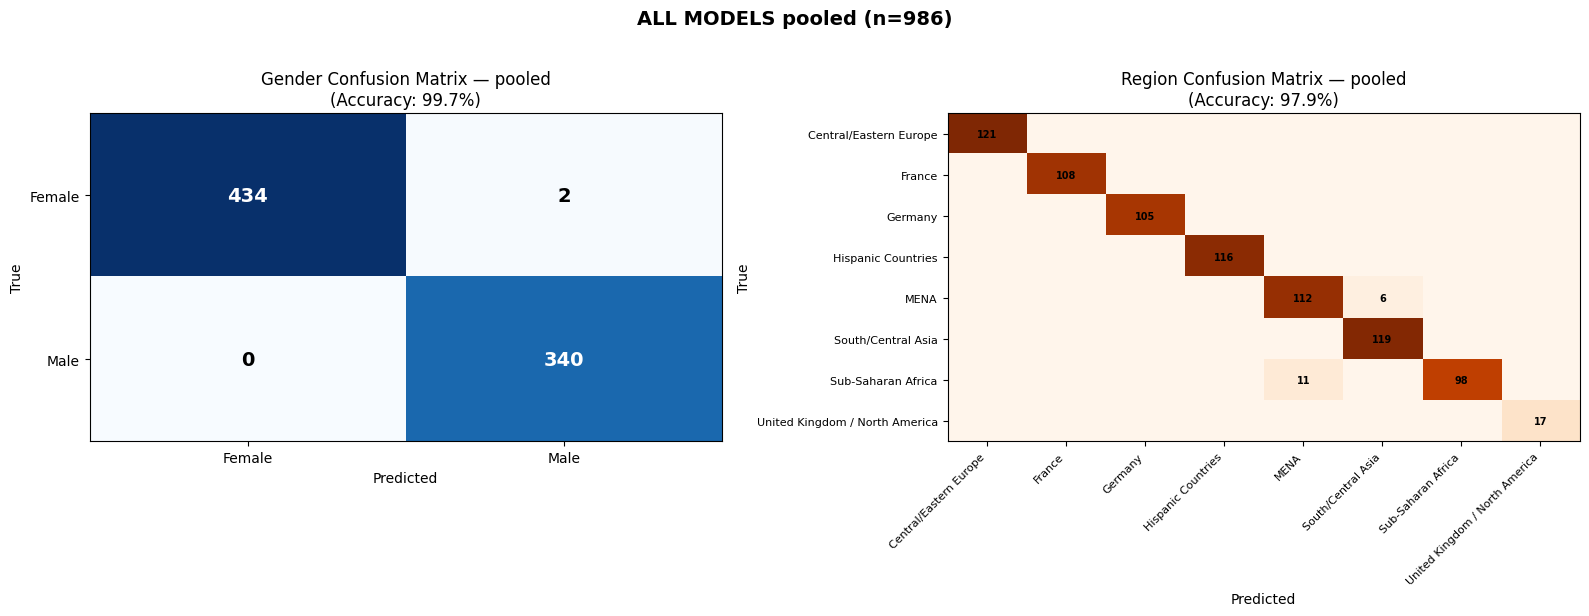

In [214]:
# --- Pooled confusion matrices across ALL models combined ---
def _safe(name: str) -> str:
    """Filesystem-safe token for figure filenames."""
    return name.replace("/", "_").replace(" ", "_")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"ALL MODELS pooled (n={len(df)})", fontsize=14, fontweight="bold", y=1.02)

# --- Gender ---
gender_ct = pd.crosstab(df["true_gender"], df["predicted_gender"])
ax = axes[0]
ax.imshow(gender_ct.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_yticks(range(len(gender_ct.index)))
ax.set_xticklabels(gender_ct.columns)
ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Gender Confusion Matrix — pooled\n(Accuracy: {df['gender_correct'].mean():.1%})")
_gmax = gender_ct.values.max()
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        _v = gender_ct.values[i, j]
        _tc = "white" if _gmax and _v > 0.5 * _gmax else "black"
        ax.text(j, i, str(_v), ha="center", va="center", fontsize=14, fontweight="bold", color=_tc)

# --- Region ---
region_ct = pd.crosstab(df["true_region"], df["predicted_region"]).reindex(index=ALL_REGIONS, columns=ALL_REGIONS, fill_value=0)
ax = axes[1]
ax.imshow(region_ct.values, cmap="Oranges", aspect="auto")
ax.set_xticks(range(len(region_ct.columns)))
ax.set_yticks(range(len(region_ct.index)))
ax.set_xticklabels(region_ct.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(region_ct.index, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Region Confusion Matrix — pooled\n(Accuracy: {df['region_correct'].mean():.1%})")
for i in range(len(region_ct.index)):
    for j in range(len(region_ct.columns)):
        v = region_ct.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=7, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_confusion_pooled_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

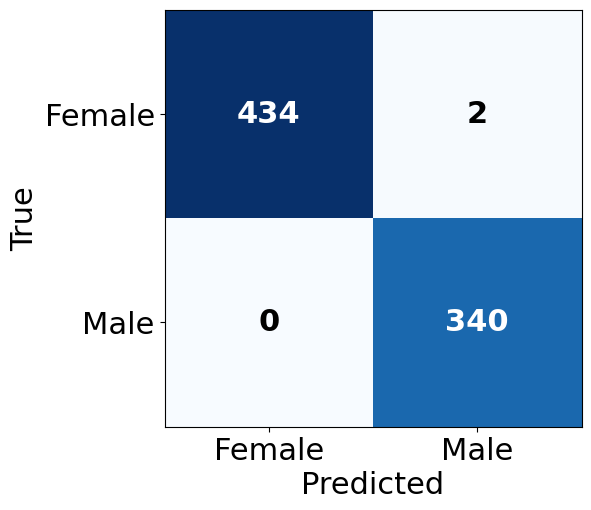

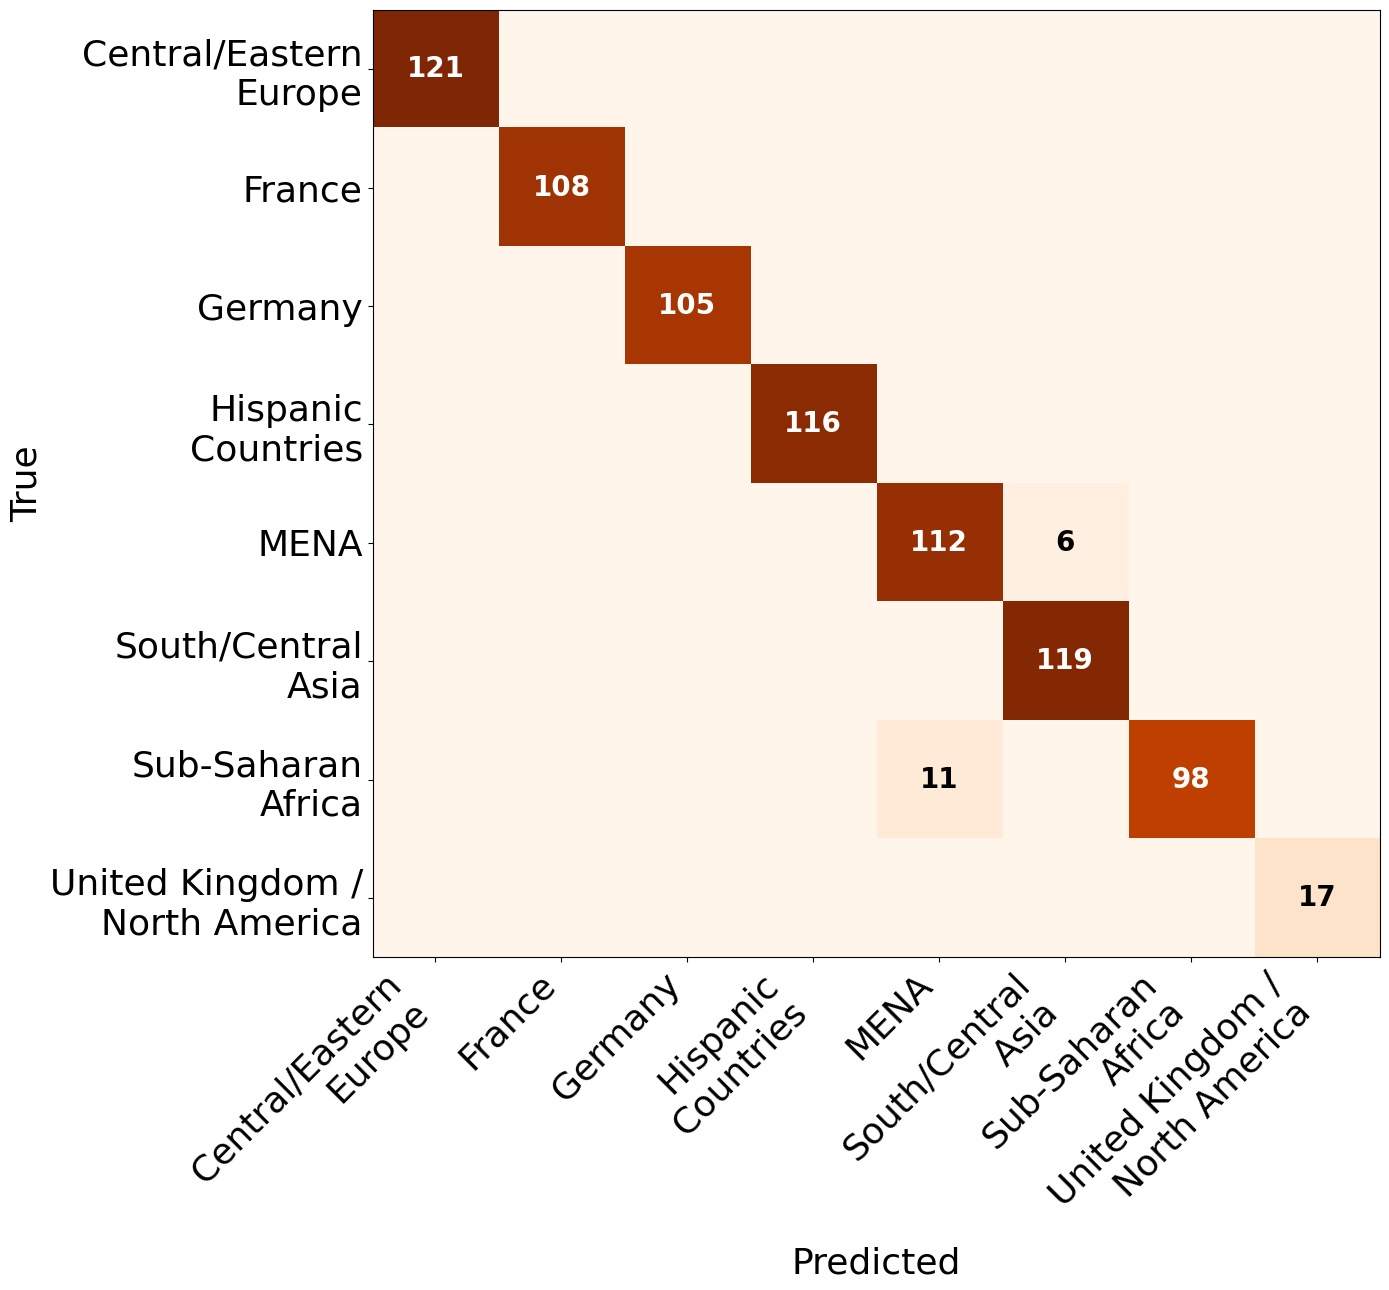

In [215]:
# --- Pooled confusion matrices — the two matrices as SEPARATE figures, no titles ---
# Paper-ready: no suptitle / axis titles, just the matrices with tick labels + counts.
# Large text matched to the baseline paper figure (tick/axis 22, cell numbers scaled up).
import textwrap

def _wrap(label, width=14):
    """Wrap a long category label onto multiple lines for readability.

    Break on a spaced ' / ' first (so "United Kingdom / North America" becomes exactly
    two lines). Tight slashes like "Central/Eastern" have no surrounding spaces, so
    they are left intact and only word-wrapped.
    """
    if " / " in label:
        return " /\n".join(p.strip() for p in label.split(" / "))
    return "\n".join(textwrap.wrap(label, width=width, break_long_words=False))

FS_TICK = 22    # gender tick (category) labels
FS_AXIS = 22    # gender "True" / "Predicted" axis labels
FS_CELL_G = 22  # gender cell counts (match tick/axis text size)
FS_TICK_R = 26  # region tick labels (a bit bigger than gender)
FS_AXIS_R = 26  # region axis labels (match region tick size)
FS_CELL_R = 20  # region cell counts (bigger)

# --- Gender (own figure) — smaller matrix, cell numbers same size as the text ---
gender_ct = pd.crosstab(df["true_gender"], df["predicted_gender"])
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(gender_ct.values, cmap="Blues", aspect="equal")
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_yticks(range(len(gender_ct.index)))
ax.set_xticklabels(gender_ct.columns, fontsize=FS_TICK)
ax.set_yticklabels(gender_ct.index, fontsize=FS_TICK)
ax.set_xlabel("Predicted", fontsize=FS_AXIS)
ax.set_ylabel("True", fontsize=FS_AXIS)
_gmax = gender_ct.values.max()
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        _v = gender_ct.values[i, j]
        _tc = "white" if _gmax and _v > 0.5 * _gmax else "black"
        ax.text(j, i, str(_v), ha="center", va="center",
                fontsize=FS_CELL_G, fontweight="bold", color=_tc)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_confusion_gender_pooled_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

# --- Region (own figure) — bigger labels + numbers, long labels wrapped ---
region_ct = pd.crosstab(df["true_region"], df["predicted_region"]).reindex(index=ALL_REGIONS, columns=ALL_REGIONS, fill_value=0)
fig, ax = plt.subplots(figsize=(14, 13))
ax.imshow(region_ct.values, cmap="Oranges", aspect="auto")
ax.set_xticks(range(len(region_ct.columns)))
ax.set_yticks(range(len(region_ct.index)))
ax.set_xticklabels([_wrap(c) for c in region_ct.columns], rotation=45, ha="right", fontsize=FS_TICK_R)
ax.set_yticklabels([_wrap(r) for r in region_ct.index], fontsize=FS_TICK_R)
ax.set_xlabel("Predicted", fontsize=FS_AXIS_R)
ax.set_ylabel("True", fontsize=FS_AXIS_R)
_rmax = region_ct.values.max()
for i in range(len(region_ct.index)):
    for j in range(len(region_ct.columns)):
        v = region_ct.values[i, j]
        if v > 0:
            _tc = "white" if _rmax and v > 0.5 * _rmax else "black"
            ax.text(j, i, str(v), ha="center", va="center",
                    fontsize=FS_CELL_R, fontweight="bold", color=_tc)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_confusion_region_pooled_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

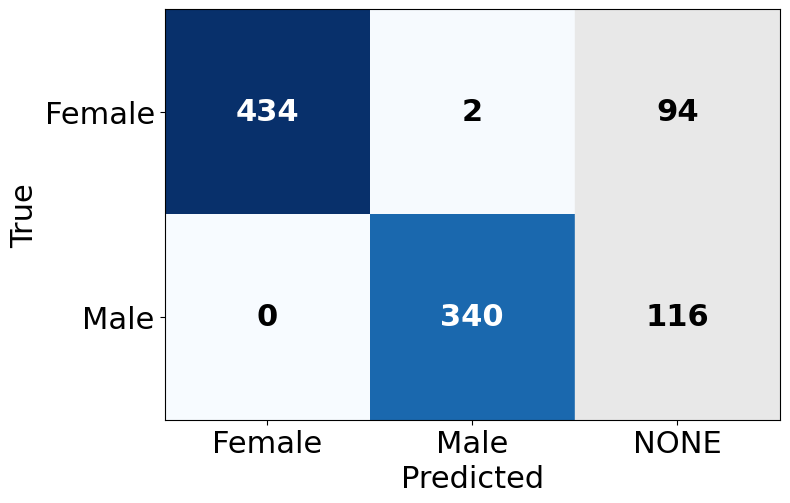

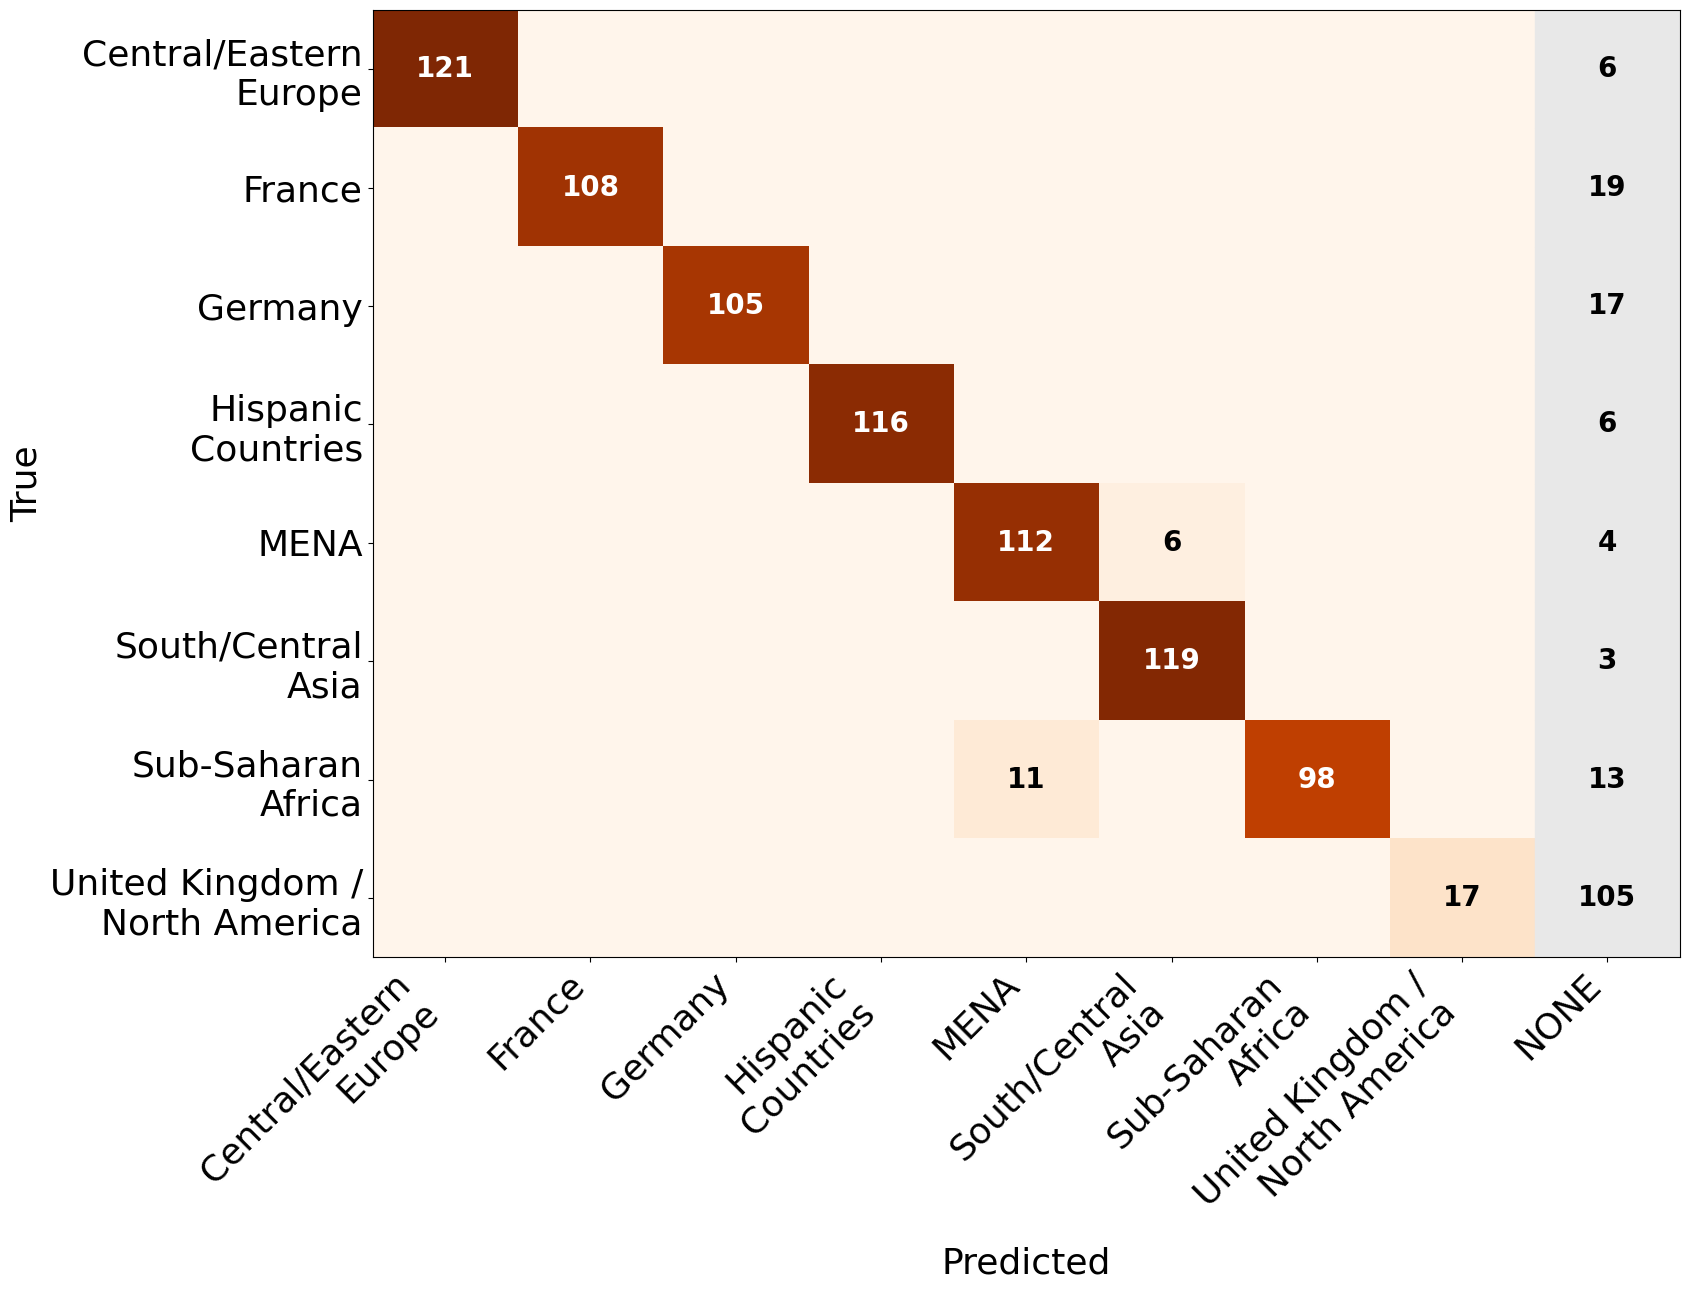

In [216]:
# --- Pooled confusion matrices WITH __NONE__ column — paper-ready separate figures ---
# Same style as the cell above, but each matrix gets one extra "NONE" column
# on the right showing how many rows per true-class the model gave no answer on
# that axis. The "NONE" column is drawn with a light grey background (not part of
# the imshow colormap) so it is visually distinct from the prediction columns.

# reuse font-size constants from the cell above (FS_TICK, FS_AXIS, etc.)
# reuse _wrap() helper from the cell above

# --- Gender with __NONE__ ---
gender_ct = pd.crosstab(df["true_gender"], df["predicted_gender"])
gender_none_per_true = df.groupby("true_gender")["gender_none"].sum().astype(int)

rows_g = gender_ct.index.tolist()
cols_g = gender_ct.columns.tolist()
n_rows_g = len(rows_g)
n_cols_g = len(cols_g)

# Build display matrix: prediction columns + NONE column
mat_g = np.zeros((n_rows_g, n_cols_g + 1), dtype=float)
mat_g[:, :n_cols_g] = gender_ct.values.astype(float)
# NONE column gets NaN so imshow masks it; we paint the background manually
mat_g[:, n_cols_g] = np.nan

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mat_g[:, :n_cols_g], cmap="Blues", aspect="equal",
               extent=[-0.5, n_cols_g - 0.5, n_rows_g - 0.5, -0.5])

# grey background for the NONE column
for i in range(n_rows_g):
    ax.add_patch(plt.Rectangle((n_cols_g - 0.5, i - 0.5), 1, 1,
                                color="#E8E8E8", zorder=0))

ax.set_xlim(-0.5, n_cols_g + 0.5)
ax.set_ylim(n_rows_g - 0.5, -0.5)

ax.set_xticks(range(n_cols_g + 1))
ax.set_yticks(range(n_rows_g))
ax.set_xticklabels(cols_g + ["NONE"], fontsize=FS_TICK)
ax.set_yticklabels(rows_g, fontsize=FS_TICK)
ax.set_xlabel("Predicted", fontsize=FS_AXIS)
ax.set_ylabel("True", fontsize=FS_AXIS)

_gmax = gender_ct.values.max()
for i, row in enumerate(rows_g):
    # prediction cells
    for j, col in enumerate(cols_g):
        v = gender_ct.values[i, j]
        tc = "white" if _gmax and v > 0.5 * _gmax else "black"
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=FS_CELL_G, fontweight="bold", color=tc)
    # NONE cell
    nv = int(gender_none_per_true.get(row, 0))
    ax.text(n_cols_g, i, str(nv), ha="center", va="center",
            fontsize=FS_CELL_G, fontweight="bold", color="black")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_confusion_gender_pooled_with_none_{RUN_TAG}.png",
            bbox_inches="tight", dpi=150)
plt.show()

# --- Region with __NONE__ ---
region_ct = pd.crosstab(df["true_region"], df["predicted_region"]).reindex(
    index=ALL_REGIONS, columns=ALL_REGIONS, fill_value=0)
region_none_per_true = df.groupby("true_region")["region_none"].sum().reindex(ALL_REGIONS, fill_value=0).astype(int)

n_rows_r = len(ALL_REGIONS)
n_cols_r = len(ALL_REGIONS)

fig, ax = plt.subplots(figsize=(17, 13))
im = ax.imshow(region_ct.values.astype(float), cmap="Oranges", aspect="auto",
               extent=[-0.5, n_cols_r - 0.5, n_rows_r - 0.5, -0.5])

for i in range(n_rows_r):
    ax.add_patch(plt.Rectangle((n_cols_r - 0.5, i - 0.5), 1, 1,
                                color="#E8E8E8", zorder=0))

ax.set_xlim(-0.5, n_cols_r + 0.5)
ax.set_ylim(n_rows_r - 0.5, -0.5)

ax.set_xticks(range(n_cols_r + 1))
ax.set_yticks(range(n_rows_r))
ax.set_xticklabels([_wrap(c) for c in ALL_REGIONS] + ["NONE"],
                   rotation=45, ha="right", fontsize=FS_TICK_R)
ax.set_yticklabels([_wrap(r) for r in ALL_REGIONS], fontsize=FS_TICK_R)
ax.set_xlabel("Predicted", fontsize=FS_AXIS_R)
ax.set_ylabel("True", fontsize=FS_AXIS_R)

_rmax = region_ct.values.max()
for i, row in enumerate(ALL_REGIONS):
    for j in range(n_cols_r):
        v = region_ct.values[i, j]
        if v > 0:
            tc = "white" if _rmax and v > 0.5 * _rmax else "black"
            ax.text(j, i, str(v), ha="center", va="center",
                    fontsize=FS_CELL_R, fontweight="bold", color=tc)
    nv = int(region_none_per_true.get(row, 0))
    ax.text(n_cols_r, i, str(nv), ha="center", va="center",
            fontsize=FS_CELL_R, fontweight="bold", color="black")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_confusion_region_pooled_with_none_{RUN_TAG}.png",
            bbox_inches="tight", dpi=150)
plt.show()

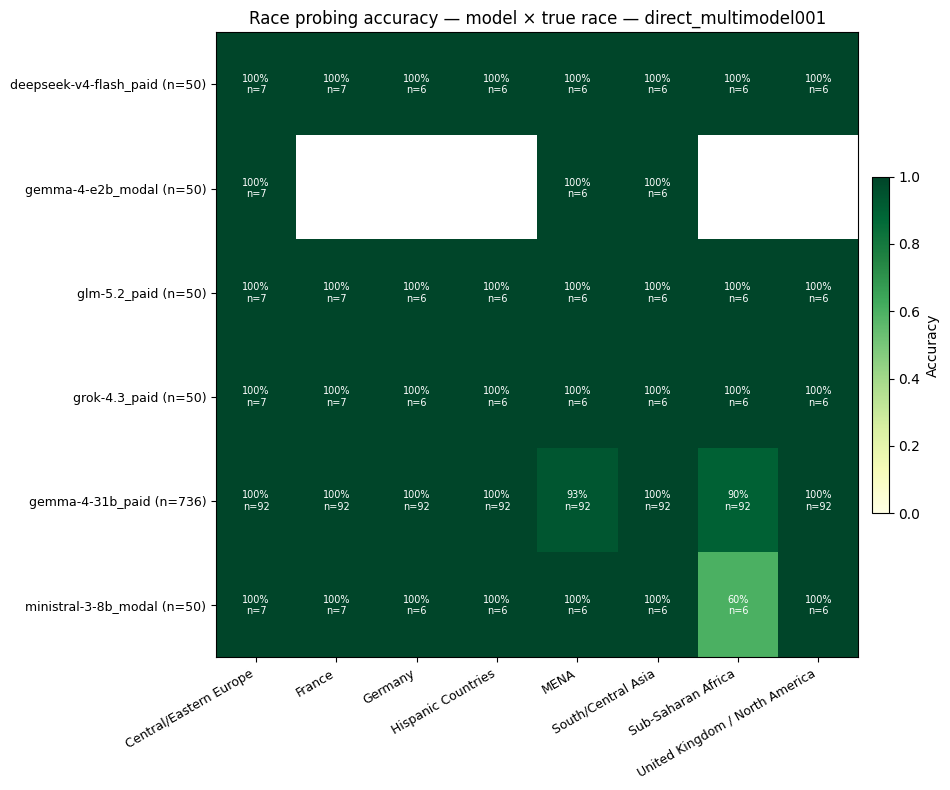

In [217]:
# --- Region × model accuracy heatmap (cross-model comparison at a glance) ---
# rows = models (ordered by overall both-accuracy), cols = true region, cell = region_correct mean
# NOTE: region_correct is a nullable boolean (NA where the model gave __NONE__ on the region axis),
# so groupby().mean() yields a nullable Float64 -> cast to plain float64 for matplotlib
# (imshow / np.isnan can't handle the object/NA dtype).
race_by_model = (
    df.groupby(["model", "true_region"])["region_correct"].mean()
      .unstack("true_region")
      .reindex(index=models, columns=ALL_REGIONS)
      .astype("float64")
)
counts_by_model = (
    df.groupby(["model", "true_region"]).size()
      .unstack("true_region")
      .reindex(index=models, columns=ALL_REGIONS)
      .fillna(0)
)

fig, ax = plt.subplots(figsize=(max(9, 0.95 * len(ALL_REGIONS) + 2), 1.0 * len(models) + 2))
im = ax.imshow(race_by_model.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_REGIONS)))
ax.set_yticks(range(len(models)))
ax.set_xticklabels(ALL_REGIONS, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels([f"{m} (n={int(overview.loc[m, 'n'])})" for m in models], fontsize=9)
ax.set_title(f"Region probing accuracy — model × true region — {RUN_TAG}")
for i in range(race_by_model.shape[0]):
    for j in range(race_by_model.shape[1]):
        v = race_by_model.values[i, j]
        n = counts_by_model.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\nn={int(n)}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.55 else "black")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Accuracy")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_race_by_model_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

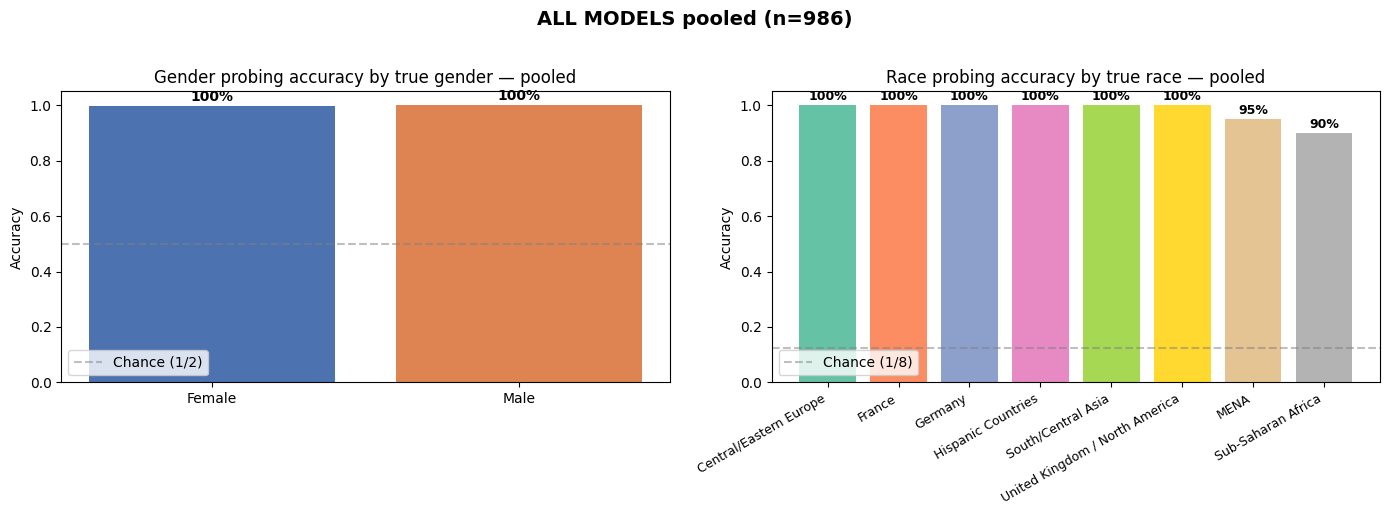

In [218]:
# --- Accuracy bars by group — ALL models pooled ---
n_regions = len(ALL_REGIONS)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"ALL MODELS pooled (n={len(df)})", fontsize=14, fontweight="bold", y=1.02)

# --- Gender accuracy by true gender ---
ax = axes[0]
gender_acc = df.groupby("true_gender")["gender_correct"].mean()
bars = ax.bar(gender_acc.index, gender_acc.values, color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Gender probing accuracy by true gender — pooled")
ax.axhline(0.5, ls="--", color="gray", alpha=0.5, label="Chance (1/2)")
for bar, val in zip(bars, gender_acc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold")
ax.legend()

# --- Region accuracy by true region ---
ax = axes[1]
region_acc = df.groupby("true_region")["region_correct"].mean().sort_values(ascending=False).dropna()
bars = ax.bar(range(len(region_acc)), region_acc.values, color=plt.cm.Set2(np.linspace(0, 1, len(region_acc))))
ax.set_xticks(range(len(region_acc)))
ax.set_xticklabels(region_acc.index, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Region probing accuracy by true region — pooled")
ax.axhline(1 / n_regions, ls="--", color="gray", alpha=0.5, label=f"Chance (1/{n_regions})")
for bar, val in zip(bars, region_acc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold", fontsize=9)
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_accuracy_bars_pooled_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

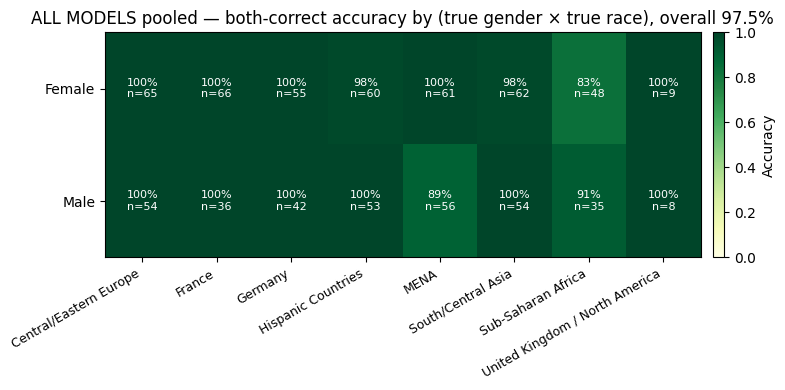

In [219]:
# --- Combined accuracy heatmap (gender × region) — ALL models pooled ---
# both_correct is a nullable boolean (NA if either axis is __NONE__); .agg("count") counts
# only rows where BOTH axes were predicted, and pivot_mean is cast to float64 so
# matplotlib / np.isnan handle the NA cells.
combined = (
    df.groupby(["true_gender", "true_region"])["both_correct"]
      .agg(["mean", "count"])
      .reset_index()
)
pivot_mean  = combined.pivot(index="true_gender", columns="true_region", values="mean").reindex(columns=ALL_REGIONS).astype("float64")
pivot_count = combined.pivot(index="true_gender", columns="true_region", values="count").reindex(columns=ALL_REGIONS)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(ALL_REGIONS)), 4))
im = ax.imshow(pivot_mean.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_REGIONS)))
ax.set_yticks(range(len(pivot_mean.index)))
ax.set_xticklabels(ALL_REGIONS, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(pivot_mean.index)
ax.set_title(f"ALL MODELS pooled — both-correct accuracy by (true gender × true region), overall {df['both_correct'].mean():.1%}")
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        v = pivot_mean.values[i, j]
        n = pivot_count.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\nn={int(n)}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.55 else "black")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Accuracy")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_combined_accuracy_pooled_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. Accuracy summary — per model

Model-specific breakdown of gender / region / combined accuracy, by true group.

In [220]:
sep = "=" * 60
n_regions = len(ALL_REGIONS)

for model in MODELS:
    d = df[df["model"] == model]
    print("\n" + "#" * 60)
    print(f"# MODEL: {model}   (n={len(d)})")
    print("#" * 60)

    print(f"\n{sep}\nGENDER PROBING\n{sep}")
    print(f"Overall accuracy: {d['gender_correct'].mean():.1%}")
    print("\nBy true gender:")
    print(d.groupby("true_gender")["gender_correct"].agg(["mean", "count"]).to_string(float_format="{:.3f}".format))

    print(f"\n{sep}\nRACE PROBING\n{sep}")
    print(f"Overall accuracy: {d['region_correct'].mean():.1%}")
    print(f"Chance level    : {1/n_regions:.1%}")
    print("\nBy true region:")
    print(d.groupby("true_region")["region_correct"].agg(["mean", "count"]).sort_values("mean", ascending=False).to_string(float_format="{:.3f}".format))

    print(f"\n{sep}\nCOMBINED (both correct)\n{sep}")
    print(f"Overall: {d['both_correct'].mean():.1%}")


############################################################
# MODEL: deepseek-v4-flash_paid   (n=50)
############################################################

GENDER PROBING
Overall accuracy: 100.0%

By true gender:
             mean  count
true_gender             
Female      1.000     24
Male        1.000     21

RACE PROBING
Overall accuracy: 100.0%
Chance level    : 12.5%

By true region:
                                mean  count
true_region                                  
Central/Eastern Europe         1.000      7
France                         1.000      7
Germany                        1.000      5
Hispanic Countries             1.000      6
MENA                           1.000      6
South/Central Asia             1.000      6
Sub-Saharan Africa             1.000      5
United Kingdom / North America 1.000      4

COMBINED (both correct)
Overall: 100.0%

############################################################
# MODEL: gemma-4-31b_paid   (n=736)
#################

## 4. Confusion matrices — per model

In [221]:
for model in MODELS:
    d = df[df["model"] == model]
    print("#" * 60)
    print(f"# MODEL: {model}")
    print("#" * 60)
    print("Gender confusion matrix:")
    print(pd.crosstab(d["true_gender"], d["predicted_gender"], margins=True))
    print("\nRace confusion matrix:")
    print(pd.crosstab(d["true_region"], d["predicted_region"], margins=True))
    print()

############################################################
# MODEL: deepseek-v4-flash_paid
############################################################
Gender confusion matrix:
predicted_gender  Female  Male  All
true_gender                        
Female                24     0   24
Male                   0    21   21
All                   24    21   45

Region confusion matrix:
predicted_region                  Central/Eastern Europe  France  Germany  \
true_region                                                                 
Central/Eastern Europe                               7       0        0   
France                                               0       7        0   
Germany                                              0       0        5   
Hispanic Countries                                   0       0        0   
MENA                                                 0       0        0   
South/Central Asia                                   0       0        0   
Sub-Saharan

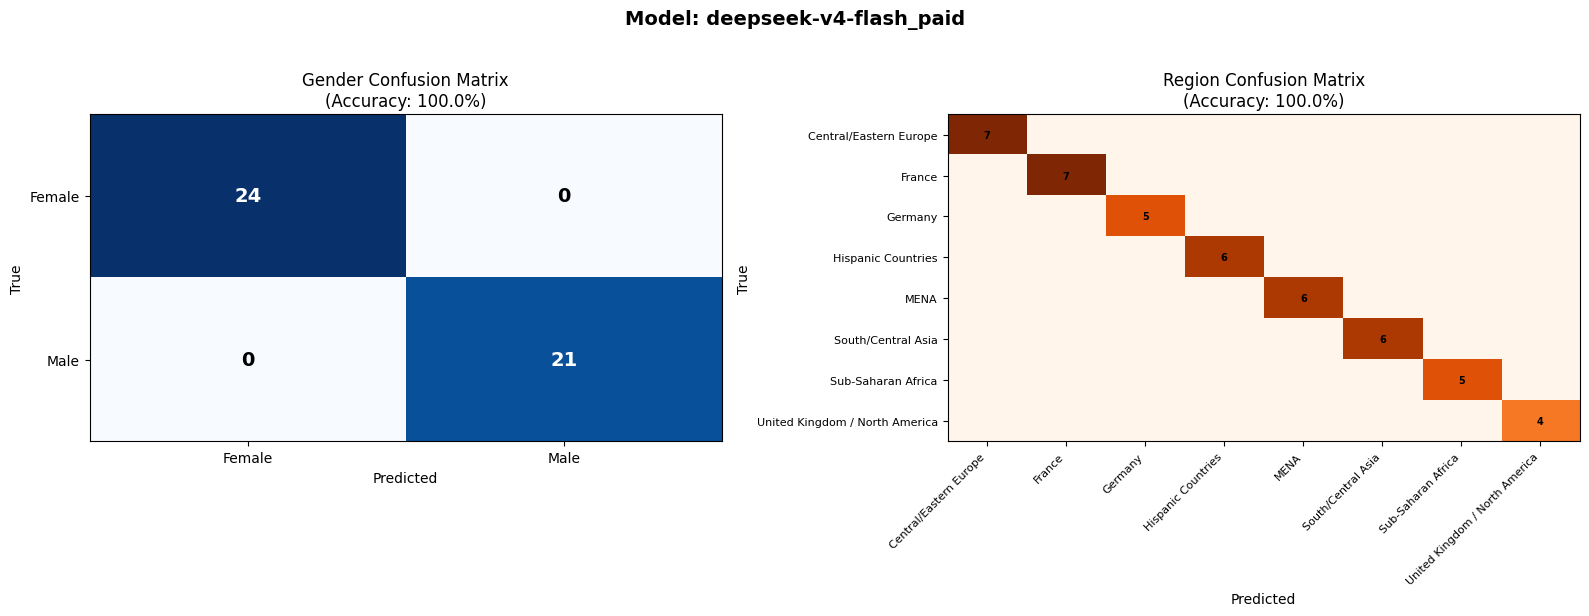

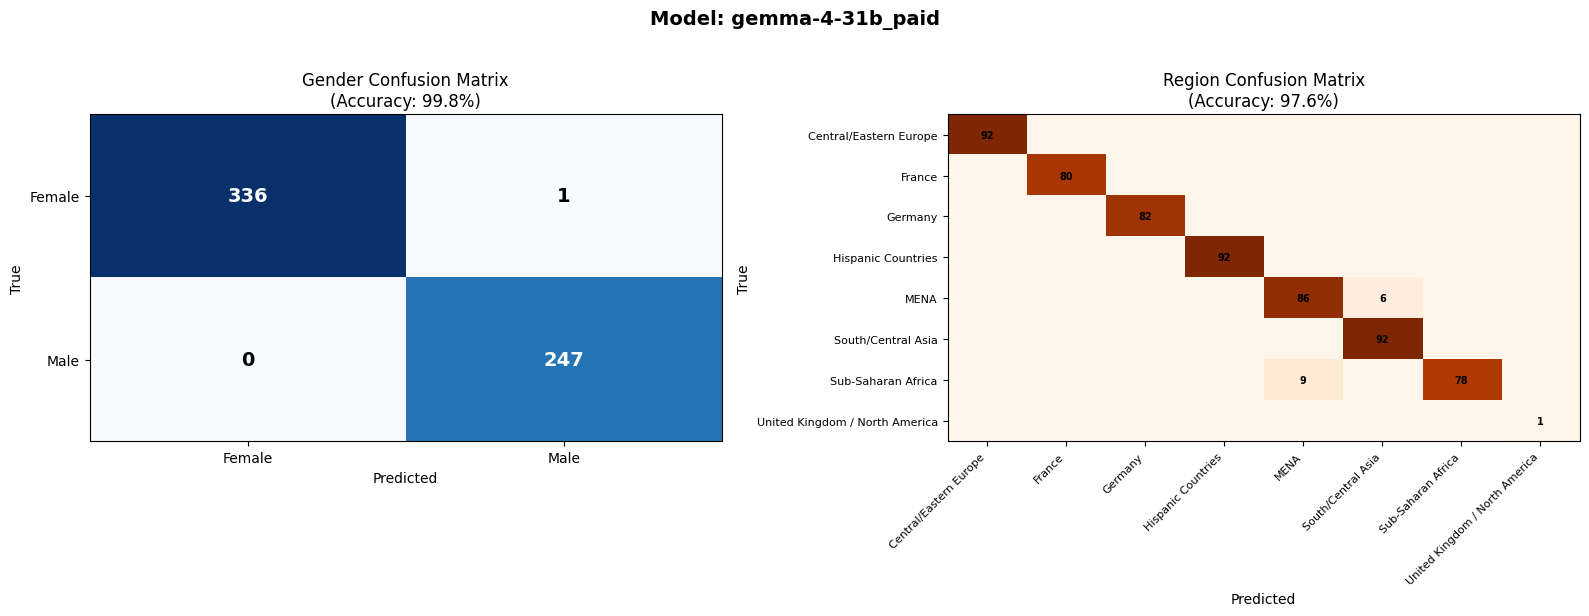

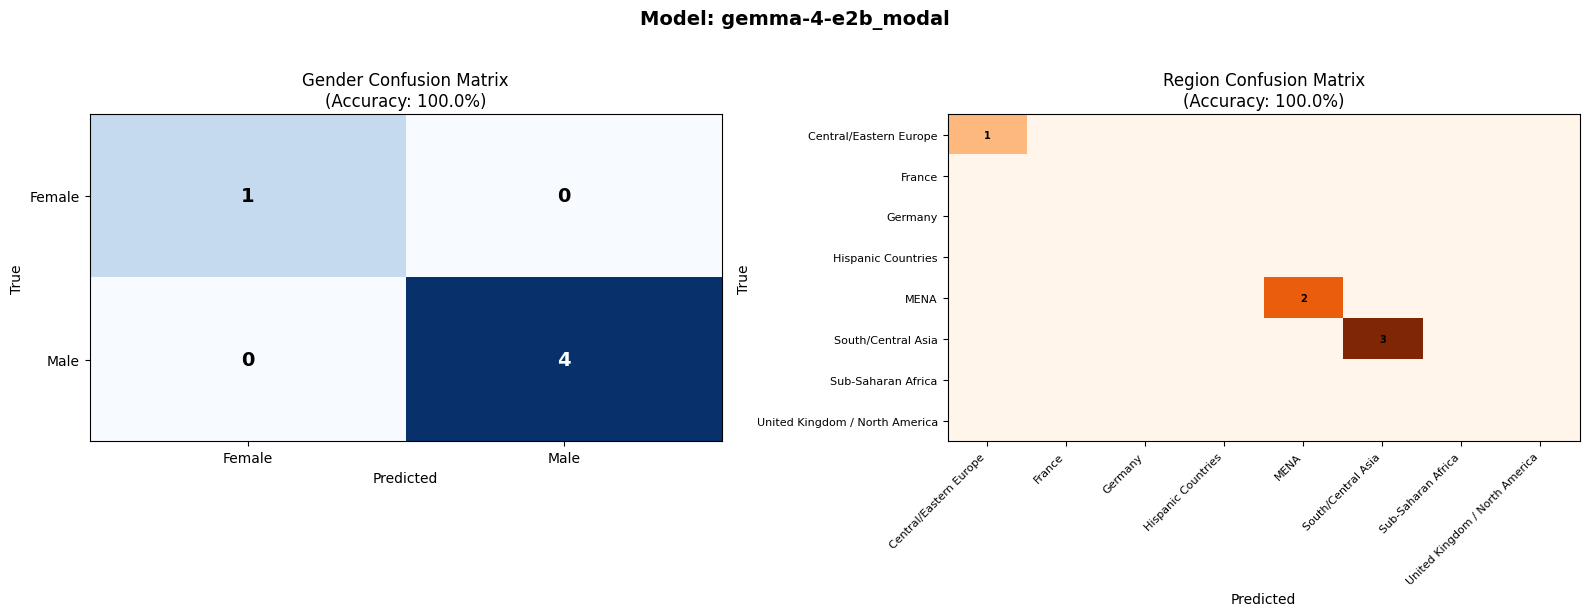

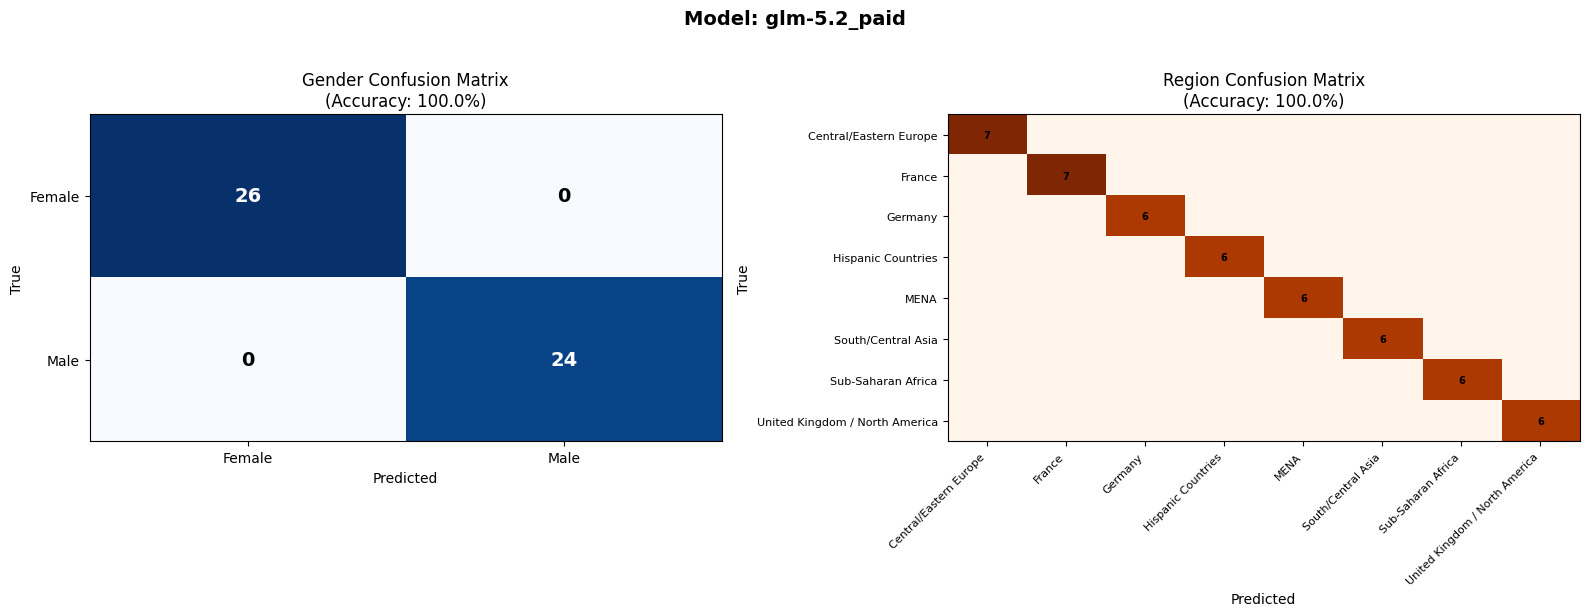

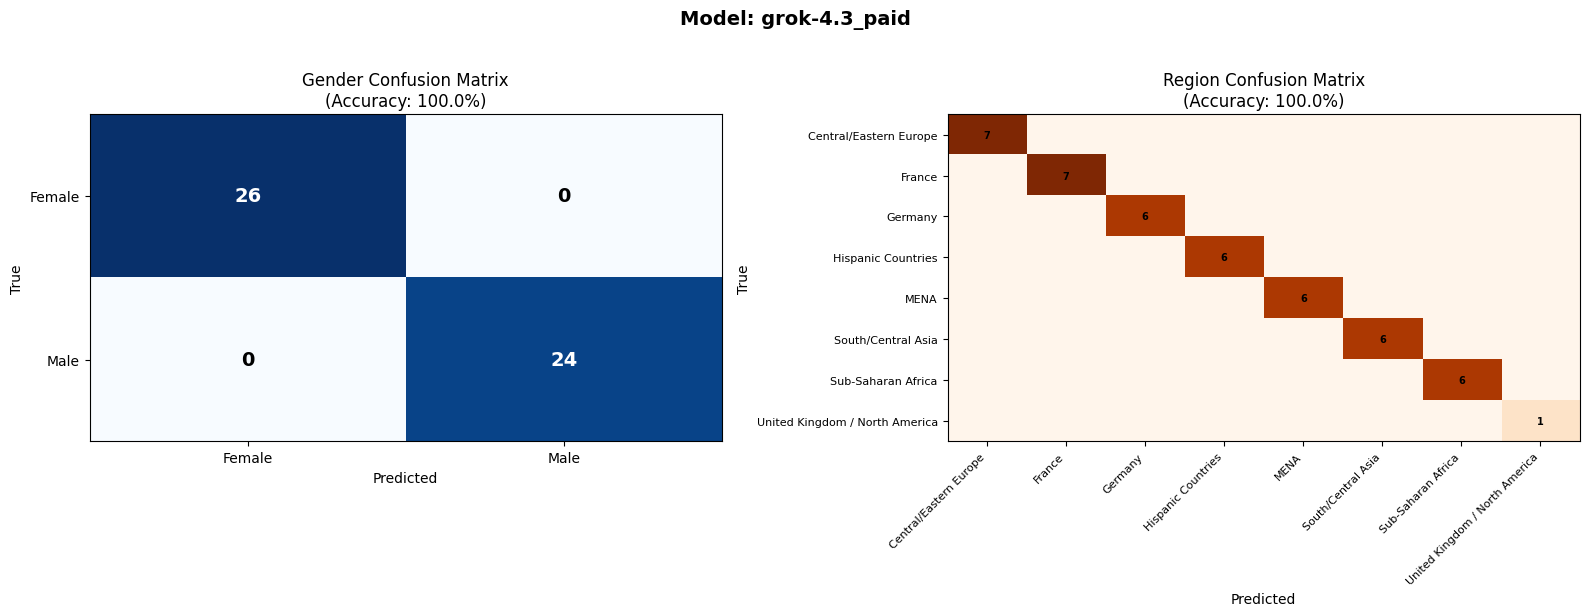

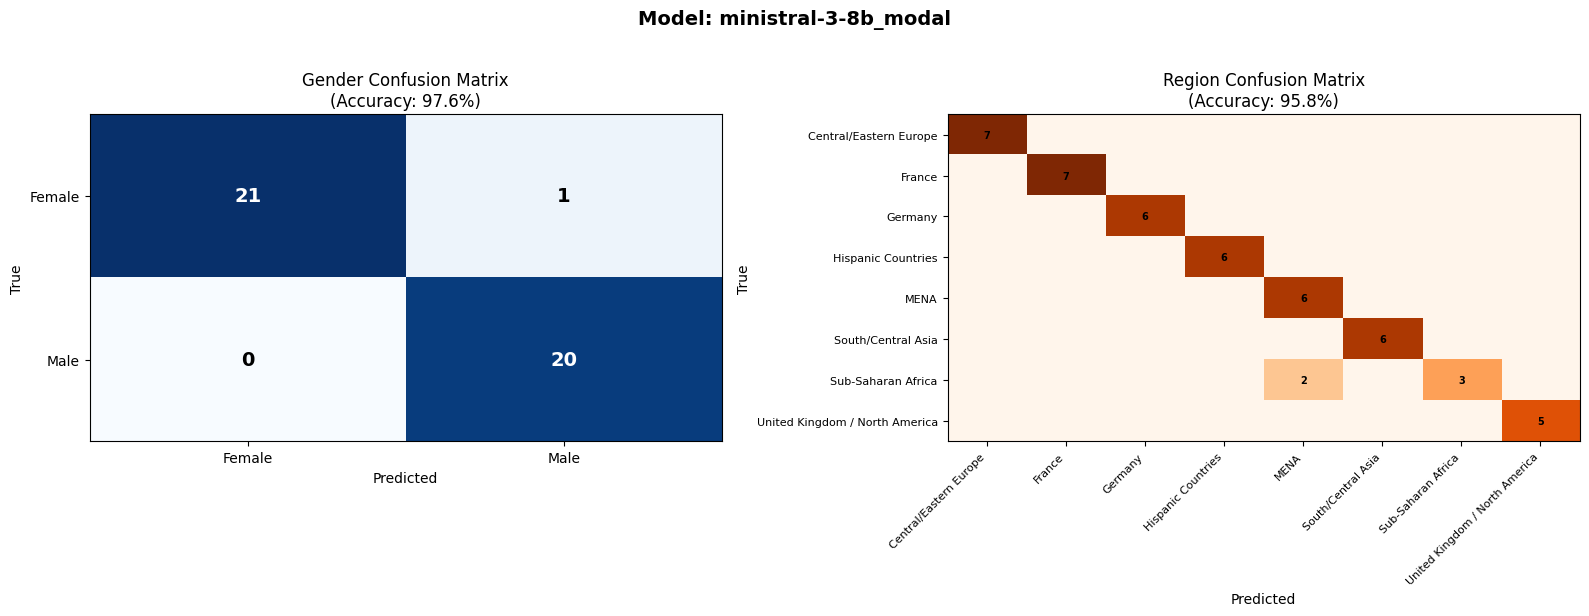

In [222]:
def _safe(name: str) -> str:
    """Filesystem-safe model token for figure filenames."""
    return name.replace("/", "_").replace(" ", "_")


for model in MODELS:
    d = df[df["model"] == model]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Model: {model}", fontsize=14, fontweight="bold", y=1.02)

    # --- Gender ---
    gender_ct = pd.crosstab(d["true_gender"], d["predicted_gender"])
    ax = axes[0]
    ax.imshow(gender_ct.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(gender_ct.columns)))
    ax.set_yticks(range(len(gender_ct.index)))
    ax.set_xticklabels(gender_ct.columns)
    ax.set_yticklabels(gender_ct.index)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Gender Confusion Matrix\n(Accuracy: {d['gender_correct'].mean():.1%})")
    _gmax = gender_ct.values.max()
    for i in range(len(gender_ct.index)):
        for j in range(len(gender_ct.columns)):
            _v = gender_ct.values[i, j]
            _tc = "white" if _gmax and _v > 0.5 * _gmax else "black"
            ax.text(j, i, str(_v), ha="center", va="center", fontsize=14, fontweight="bold", color=_tc)

    # --- Region ---
    region_ct = pd.crosstab(d["true_region"], d["predicted_region"])
    region_ct = region_ct.reindex(index=ALL_REGIONS, columns=ALL_REGIONS, fill_value=0)
    ax = axes[1]
    ax.imshow(region_ct.values, cmap="Oranges", aspect="auto")
    ax.set_xticks(range(len(region_ct.columns)))
    ax.set_yticks(range(len(region_ct.index)))
    ax.set_xticklabels(region_ct.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(region_ct.index, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Region Confusion Matrix\n(Accuracy: {d['region_correct'].mean():.1%})")
    for i in range(len(region_ct.index)):
        for j in range(len(region_ct.columns)):
            v = region_ct.values[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center", fontsize=7, fontweight="bold")

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"confusion_matrices_{RUN_TAG}_{_safe(model)}.png", bbox_inches="tight", dpi=150)
    plt.show()

## 5. Accuracy bars by group — per model

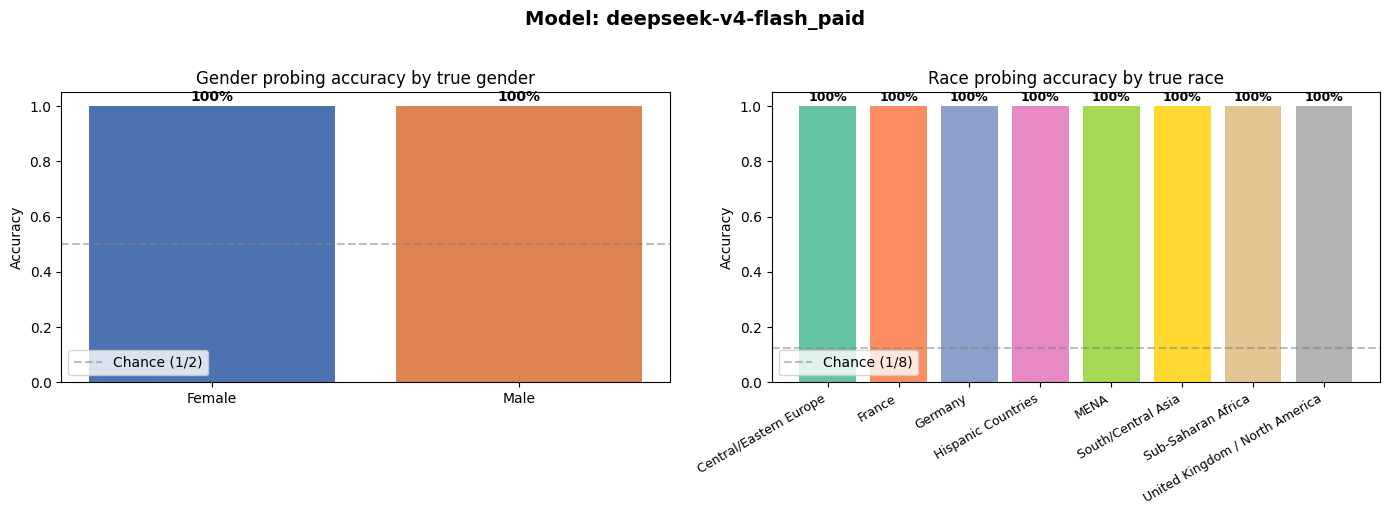

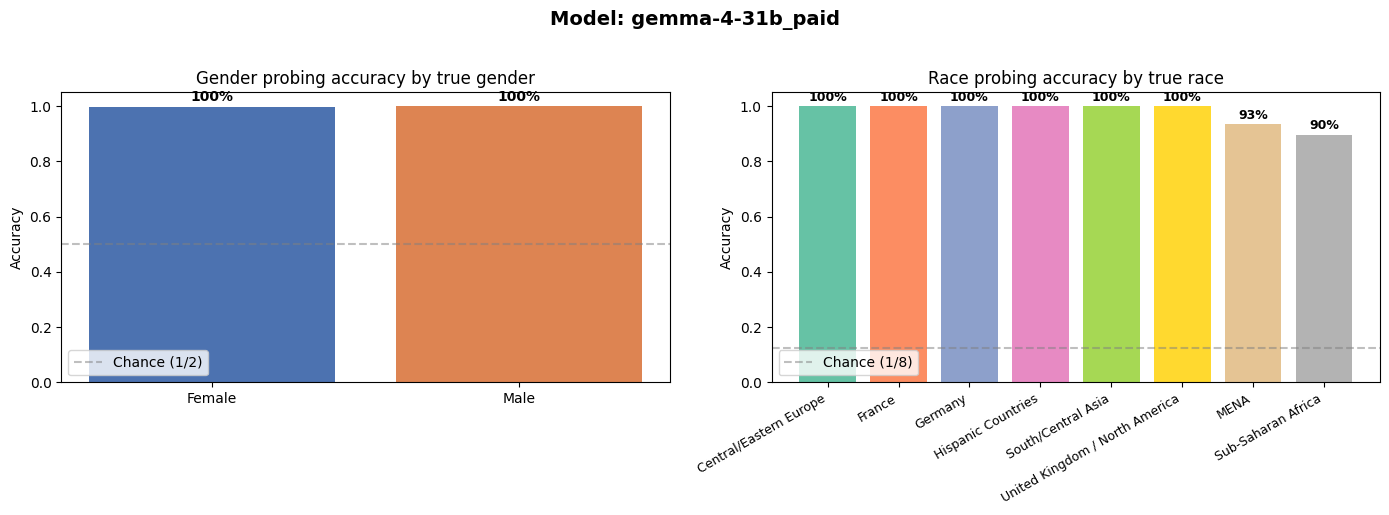

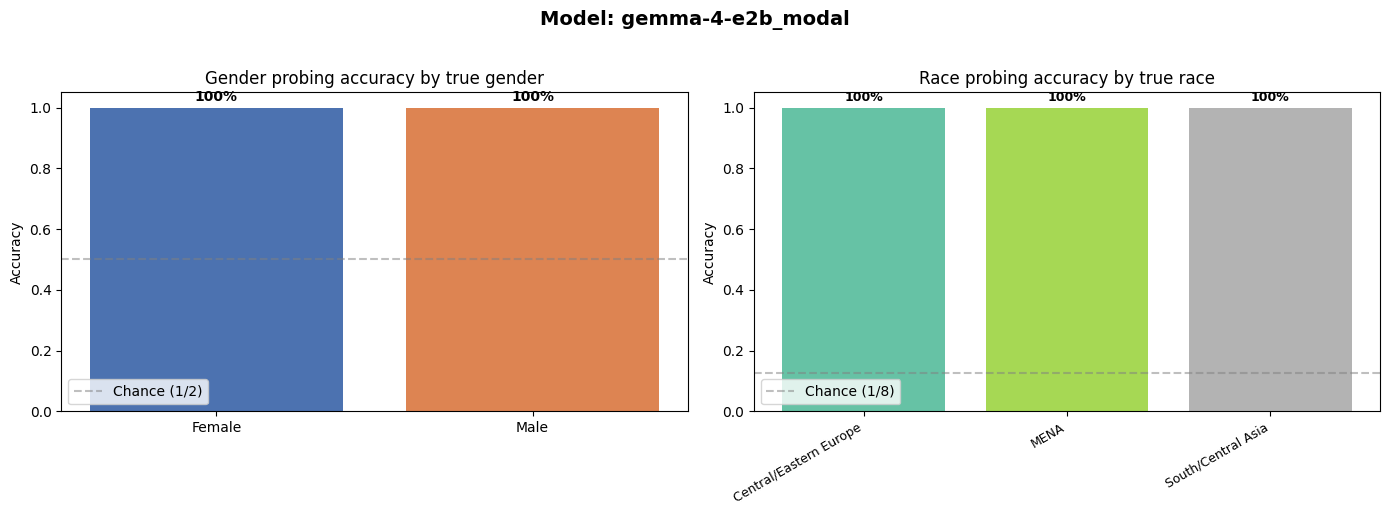

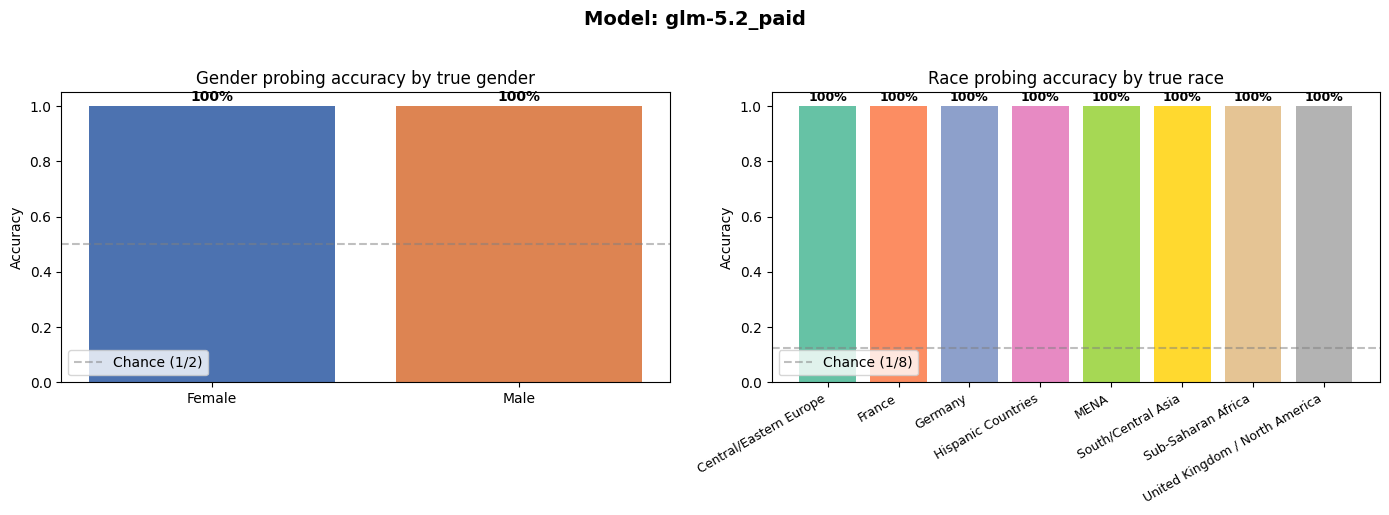

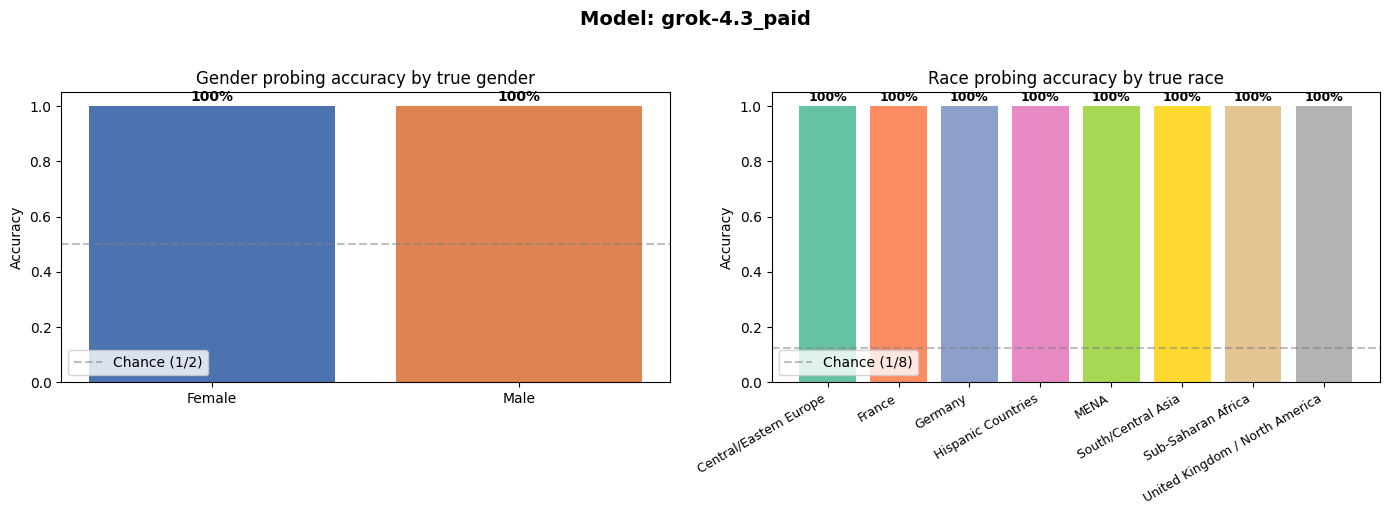

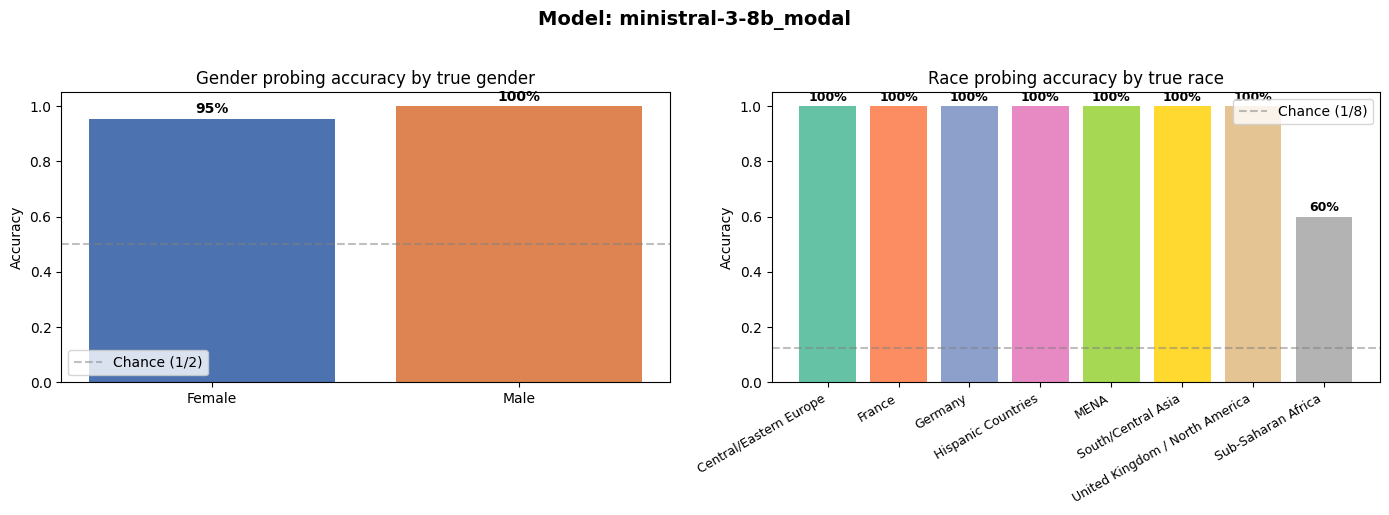

In [223]:
n_regions = len(ALL_REGIONS)

for model in MODELS:
    d = df[df["model"] == model]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Model: {model}", fontsize=14, fontweight="bold", y=1.02)

    # --- Gender accuracy by true gender ---
    ax = axes[0]
    gender_acc = d.groupby("true_gender")["gender_correct"].mean()
    bars = ax.bar(gender_acc.index, gender_acc.values, color=["#4C72B0", "#DD8452"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title("Gender probing accuracy by true gender")
    ax.axhline(0.5, ls="--", color="gray", alpha=0.5, label="Chance (1/2)")
    for bar, val in zip(bars, gender_acc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold")
    ax.legend()

    # --- Region accuracy by true region ---
    ax = axes[1]
    region_acc = d.groupby("true_region")["region_correct"].mean().sort_values(ascending=False).dropna()
    bars = ax.bar(range(len(region_acc)), region_acc.values, color=plt.cm.Set2(np.linspace(0, 1, len(region_acc))))
    ax.set_xticks(range(len(region_acc)))
    ax.set_xticklabels(region_acc.index, rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title("Region probing accuracy by true region")
    ax.axhline(1 / n_regions, ls="--", color="gray", alpha=0.5, label=f"Chance (1/{n_regions})")
    for bar, val in zip(bars, region_acc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold", fontsize=9)
    ax.legend()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"accuracy_bars_{RUN_TAG}_{_safe(model)}.png", bbox_inches="tight", dpi=150)
    plt.show()

## 6. Combined accuracy heatmap (gender × region) — per model

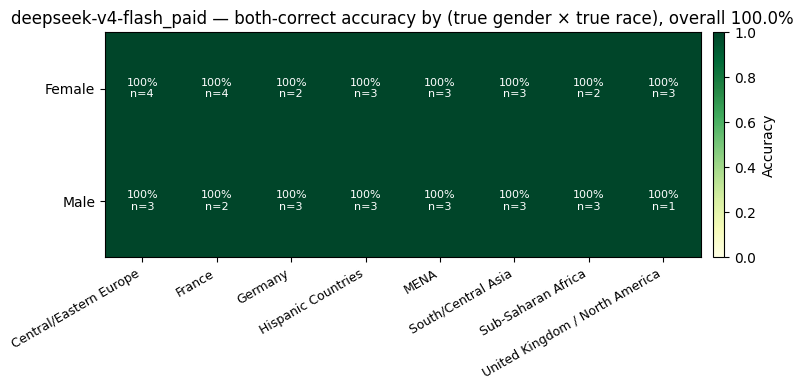

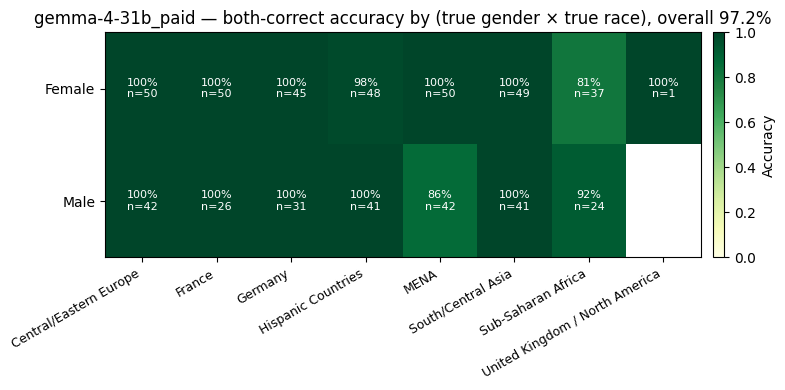

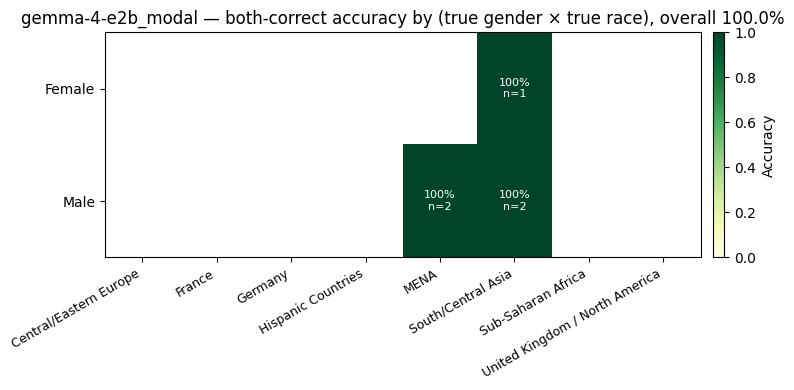

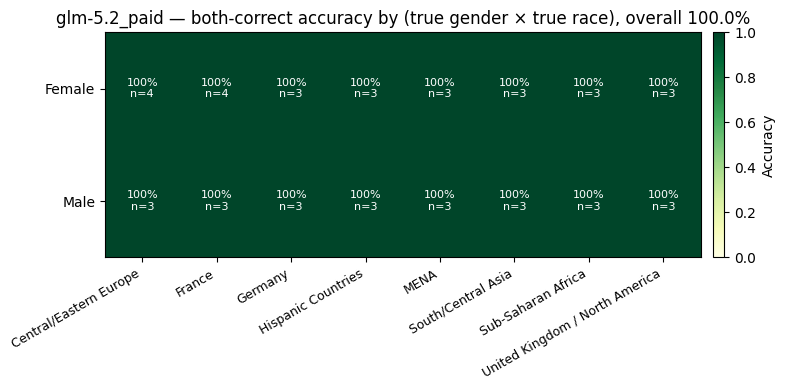

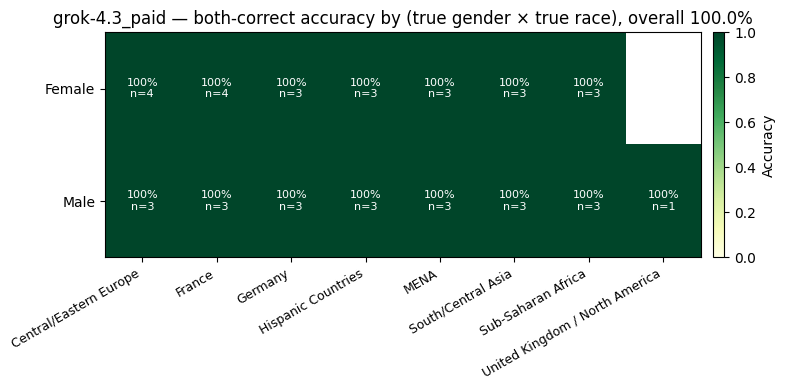

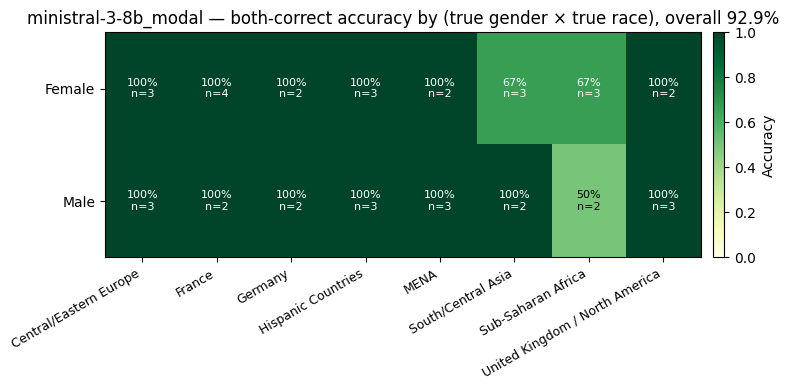

In [224]:
for model in MODELS:
    d = df[df["model"] == model]
    # both_correct rate per (true_gender × true_region) cell. both_correct is a nullable
    # boolean (NA if either axis is __NONE__); cast pivot_mean to float64 for matplotlib.
    combined = (
        d.groupby(["true_gender", "true_region"])["both_correct"]
          .agg(["mean", "count"])
          .reset_index()
    )
    pivot_mean  = combined.pivot(index="true_gender", columns="true_region", values="mean").reindex(columns=ALL_REGIONS).astype("float64")
    pivot_count = combined.pivot(index="true_gender", columns="true_region", values="count").reindex(columns=ALL_REGIONS)

    fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(ALL_REGIONS)), 4))
    im = ax.imshow(pivot_mean.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(ALL_REGIONS)))
    ax.set_yticks(range(len(pivot_mean.index)))
    ax.set_xticklabels(ALL_REGIONS, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(pivot_mean.index)
    ax.set_title(f"{model} — both-correct accuracy by (true gender × true region), overall {d['both_correct'].mean():.1%}")
    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            v = pivot_mean.values[i, j]
            n = pivot_count.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0%}\nn={int(n)}", ha="center", va="center", fontsize=8,
                        color="white" if v > 0.55 else "black")
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Accuracy")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"combined_accuracy_{RUN_TAG}_{_safe(model)}.png", bbox_inches="tight", dpi=150)
    plt.show()